# Perfilado de Datos · Calidad y Preprocesamiento
**Equipo:** Calidad de Datos (Carlo Kiliano Ferrera, José Julian Pérez, Aldo Sebastián Altamirano)
**Curso:** Calidad y Preprocesamiento de Datos · Licenciatura en Ciencia de Datos · IIMAS UNAM CU · 2026‑2
**Framework:** DAMA‑DMBOK · Fase *Assess*

> "Limpiar el agua es lo que necesita el México de hoy: la inacción es más cara."

---

## Objetivo del notebook
Diagnosticar el estado de calidad de las **7 fuentes de datos** del proyecto *Agua Potable en la Ciudad de México: del caos de datos a la toma de decisiones basada en evidencia* sin transformar los datos originales. Este notebook **mide**; la limpieza vive en `limpieza.py` y la fusión en `fusion.ipynb`.

## Reglas que sigue este notebook (separación de fases DAMA)
1. **Sólo se mide; no se transforma.** Cualquier subset, normalización de texto o coerción numérica se hace sobre **copias** y se descarta al final del bloque. Las decisiones de limpieza se documentan en tablas, no se ejecutan.
2. **Cada hallazgo se cuantifica.** Nada de "hay algunos nulos": siempre `n` y `%`.
3. **Cada regla de negocio es un contrato verificable** (idealmente un `assert` o una columna booleana auditable).
4. **Los outputs son artefactos de handoff:** un *Data Quality Scorecard* por fuente×dimensión, una tabla de decisión por columna para CONAGUA, y un catálogo estructurado de fuentes que `limpieza.py` consumirá.

## Estructura
0. Configuración del entorno y constantes globales
1. Funciones reutilizables de perfilado
2. Conversión de fuentes no tabulares a CSV (PDF, XML)
3. Inventario general (encoding, dimensiones, schema)
4. Perfilado por fuente siguiendo las 6 dimensiones DAMA
   * 4.1 Anuario de Morbilidad (SSA)
   * 4.2 Censo de Población y Vivienda (INEGI ITER)
   * 4.3 Pobreza por grupos poblacionales (CONEVAL)
   * 4.4 Catálogo de colonias y CP (SEPOMEX)
   * 4.5 Reportes de fugas (SACMEX) — **profundo, incluye Puntualidad**
   * 4.6 Catálogo de sitios de monitoreo (CONAGUA Sitios)
   * 4.7 Resultados de monitoreo (CONAGUA Resultados) — **incluye tabla de decisión por columna**
5. Integridad referencial cruzada
6. Conformidad regulatoria (NOM‑127‑SSA1‑2021)
7. Cobertura de granularidad geográfica entre fuentes
8. Data Quality Scorecard consolidado
9. Catálogo de fuentes (handoff a `limpieza.py`)
10. Conclusiones del perfilado

## 1. Configuración del entorno

Carga de librerías, definición de la raíz del proyecto (idéntica al notebook original) y constantes globales que rigen todo el perfilado: códigos de *missing* declarados por fuente, bounding box oficial de la CDMX, límites regulatorios NOM‑127 y umbrales de decisión para imputación.

Centralizar estas constantes evita las inconsistencias del notebook original (a veces `na_values=['*']`, a veces `replace(-999, NaN)`, a veces nada). Aquí se declaran una vez.

In [ ]:
# Instalación de dependencias (descomentar si es la primera vez)
# !pip install pandas numpy matplotlib seaborn chardet missingno pdfplumber pyxlsb openpyxl pyyaml

In [1]:
import os
import re
import json
import warnings
import unicodedata
from pathlib import Path
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chardet
from IPython.display import display, Markdown

# missingno es opcional; el perfilado no se cae si no está instalado
try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False
    print("⚠️ missingno no está instalado; las matrices de nulidad se omitirán. Instalar con: pip install missingno")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

### 1.1 Raíz del proyecto

Función idéntica a la del notebook original para mantener portabilidad entre laptops del equipo.

In [2]:
def get_project_root(marker: str = "README.md") -> Path:
    """Sube el árbol de directorios hasta hallar el archivo `marker`."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError("No se encontró la raíz del proyecto (no existe README.md hacia arriba).")

PROJECT_ROOT = get_project_root()
DATOS_CRUDOS = PROJECT_ROOT / "datos" / "datos_crudos"

print(f"📂 PROJECT_ROOT : {PROJECT_ROOT}")
print(f"📂 DATOS_CRUDOS: {DATOS_CRUDOS}")
assert DATOS_CRUDOS.exists(), f"No existe el directorio de datos crudos: {DATOS_CRUDOS}"


📂 PROJECT_ROOT : c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos
📂 DATOS_CRUDOS: c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos\datos\datos_crudos


### 1.2 Rutas a las fuentes

Una sola fuente de la verdad para las rutas. Si una se mueve, se cambia aquí y nada más.

In [3]:
RUTAS = {
    "morbilidad_ssa":   DATOS_CRUDOS / "Anuario_Morbilidad_2017.csv",
    "inegi_iter":       DATOS_CRUDOS / "conjunto_de_datos_iter_00CSV20.csv",
    "coneval_pobreza":  DATOS_CRUDOS / "pobreza_grupos_poblacionales_edad.csv",
    "sepomex":          DATOS_CRUDOS / "catalogo_sepomex.csv",
    "sacmex_reportes":  DATOS_CRUDOS / "reportes_agua_2024_01.csv",
    "conagua_sitios":   DATOS_CRUDOS / "Sitios_CONAGUA.csv",
    "conagua_result":   DATOS_CRUDOS / "Resultados_CONAGUA.csv",
    "plantas_pdf":      DATOS_CRUDOS / "Inventario_Nacional_PPyPATAR_2024_CDMX.pdf",
    "plantas_csv":      DATOS_CRUDOS / "plantas_cdmx.csv",
    "sepomex_xml":      DATOS_CRUDOS / "Ciudad de México.xml",
}

# Verificación de presencia
for nombre, ruta in RUTAS.items():
    estado = "✅" if ruta.exists() else "⚠️ (no encontrado)"
    print(f"  {estado}  {nombre:<18} -> {ruta.name}")

  ✅  morbilidad_ssa     -> Anuario_Morbilidad_2017.csv
  ✅  inegi_iter         -> conjunto_de_datos_iter_00CSV20.csv
  ✅  coneval_pobreza    -> pobreza_grupos_poblacionales_edad.csv
  ✅  sepomex            -> catalogo_sepomex.csv
  ✅  sacmex_reportes    -> reportes_agua_2024_01.csv
  ✅  conagua_sitios     -> Sitios_CONAGUA.csv
  ✅  conagua_result     -> Resultados_CONAGUA.csv
  ✅  plantas_pdf        -> Inventario_Nacional_PPyPATAR_2024_CDMX.pdf
  ✅  plantas_csv        -> plantas_cdmx.csv
  ✅  sepomex_xml        -> Ciudad de México.xml


### 1.3 Constantes globales

Estas constantes son **decisiones del proyecto** hechas explícitas. Cualquier cambio queda trazado aquí.

In [4]:
# ---------------------------------------------------------------------
# Códigos de "missing" declarados por fuente.
# Convención: cada fuente publica datos faltantes con su propia notación.
# Centralizar evita inconsistencias en el pipeline.
# ---------------------------------------------------------------------
MISSING_CODES = {
    "INEGI":   ["*", "N/D", "N/A"],          # INEGI marca confidencial con asterisco
    "CONEVAL": [-999, -999.0, "-999"],       # CONEVAL marca no-calculable con -999
    "SACMEX":  [],                            # NaN nativo de pandas
    "CONAGUA": [],                            # mediciones con prefijo '<' o 'ND' (no se transforma aquí; sólo se reporta)
    "SSA":     [],                            # imputación por ceros en origen
}

# ---------------------------------------------------------------------
# Bounding box oficial de la CDMX.
# Fuente: Marco Geoestadístico Nacional INEGI 2020 (aproximación rectangular).
# El notebook original usaba (19.0–19.6, -99.4 a -98.9) que recortaba Milpa Alta.
# ---------------------------------------------------------------------
CDMX_BBOX = {
    "lat_min": 19.05,
    "lat_max": 19.59,
    "lon_min": -99.36,
    "lon_max": -98.94,
}

# ---------------------------------------------------------------------
# Límites NOM-127-SSA1-2021 para agua de uso y consumo humano.
# OJO: las fuentes CONAGUA contienen agua *cruda* de cuerpos superficiales y
# acuíferos, NO agua potabilizada. Reportar excedencias contextualiza el riesgo,
# no implica incumplimiento legal directo de la planta.
# ---------------------------------------------------------------------
NOM_127 = {
    "AS_TOT":        {"limite": 0.010, "unidad": "mg/L",       "param": "Arsénico"},
    "PB_TOT":        {"limite": 0.010, "unidad": "mg/L",       "param": "Plomo"},
    "HG_TOT":        {"limite": 0.006, "unidad": "mg/L",       "param": "Mercurio"},
    "CD_TOT":        {"limite": 0.005, "unidad": "mg/L",       "param": "Cadmio"},
    "FLUORUROS_TOT": {"limite": 1.500, "unidad": "mg/L",       "param": "Fluoruros"},
    "N_NO3":         {"limite": 10.00, "unidad": "mg/L",       "param": "Nitratos"},
    "E_COLI":        {"limite": 0.000, "unidad": "NMP/100mL",  "param": "E. coli"},
    "COLI_FEC":      {"limite": 0.000, "unidad": "NMP/100mL",  "param": "Coliformes fecales"},
}

# ---------------------------------------------------------------------
# Umbrales para la matriz de decisión de limpieza por columna (% de nulos).
# Justificación: imputar una columna con >30% de nulos sintetiza >30% de los
# valores; en variables tóxicas (mercurio, plomo) eso equivale a fabricar
# evidencia. El umbral de 30% es práctica estándar en DAMA y en la literatura
# de imputación múltiple (Rubin, 1987; van Buuren, 2018).
# ---------------------------------------------------------------------
DECISION_THRESHOLDS = {"DROP": 95.0, "FLAG": 30.0, "IMPUTE": 5.0}

# ---------------------------------------------------------------------
# Acumulador de scores por fuente×dimensión.
# Cada bloque de perfilado deposita aquí su veredicto cuantitativo.
# Al final se construye el scorecard.
# ---------------------------------------------------------------------
SCORECARD = defaultdict(dict)
HALLAZGOS = defaultdict(list)  # texto descriptivo de findings clave

## 2. Funciones reutilizables

Centralizar las operaciones repetitivas. El perfilado del notebook original repetía bloques casi idénticos en cada fuente; aquí se factoriza para que cada fuente sólo declare sus particularidades.

In [5]:
def detectar_encoding(path: Path, sample_bytes: int = 5_000_000) -> dict:
    """Detecta codificación leyendo hasta 5 MB del archivo (vs. los 200 KB del notebook original)."""
    with open(path, "rb") as f:
        raw = f.read(sample_bytes)
    return chardet.detect(raw)


def normalizar_texto(serie: pd.Series) -> pd.Series:
    """Normaliza texto: NFKD, sin acentos, mayúsculas, sin espacios laterales.

    Se usa para *medir* coincidencias entre fuentes. NO se persiste en el dataset original.
    """
    return (serie
            .fillna("")
            .astype(str)
            .str.normalize("NFKD")
            .str.encode("ascii", errors="ignore")
            .str.decode("utf-8")
            .str.upper()
            .str.strip())


def perfil_completitud(df: pd.DataFrame, columnas=None) -> pd.Series:
    """% de nulos por columna."""
    cols = list(columnas) if columnas is not None else df.columns
    return (df[cols].isnull().mean() * 100).round(2)


def perfil_outliers_iqr(serie: pd.Series) -> dict:
    """Detección de outliers por regla IQR (1.5*IQR)."""
    s = pd.to_numeric(serie, errors="coerce").dropna()
    if len(s) == 0:
        return {"n_obs": 0, "n_outliers": 0, "pct_outliers": np.nan, "lim_inf": np.nan, "lim_sup": np.nan}
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < li) | (s > ls)).sum())
    return {"n_obs": int(len(s)), "n_outliers": n_out,
            "pct_outliers": round(100 * n_out / len(s), 2),
            "lim_inf": float(li), "lim_sup": float(ls)}


def conformidad_regulatoria(df: pd.DataFrame, reglas: dict) -> pd.DataFrame:
    """Tabla de excedencias frente a una norma."""
    rows = []
    for col, info in reglas.items():
        if col not in df.columns:
            rows.append({**info, "columna": col, "n_mediciones": 0,
                         "n_excede": 0, "pct_excede": np.nan,
                         "max_observado": np.nan, "ratio_max_vs_limite": np.nan,
                         "nota": "columna ausente"})
            continue
        # Coerción a numérico SIN persistir; los <, ND, etc. se vuelven NaN automáticamente.
        s = pd.to_numeric(df[col], errors="coerce")
        n_total = int(s.notna().sum())
        if n_total == 0:
            rows.append({**info, "columna": col, "n_mediciones": 0,
                         "n_excede": 0, "pct_excede": np.nan,
                         "max_observado": np.nan, "ratio_max_vs_limite": np.nan,
                         "nota": "todas las mediciones nulas o no numéricas"})
            continue
        n_excede = int((s > info["limite"]).sum())
        max_obs = float(s.max())
        ratio = (max_obs / info["limite"]) if info["limite"] > 0 else np.inf
        rows.append({**info, "columna": col, "n_mediciones": n_total,
                     "n_excede": n_excede,
                     "pct_excede": round(100 * n_excede / n_total, 2),
                     "max_observado": max_obs,
                     "ratio_max_vs_limite": round(ratio, 2) if np.isfinite(ratio) else None,
                     "nota": ""})
    cols_orden = ["param", "columna", "limite", "unidad", "n_mediciones",
                  "n_excede", "pct_excede", "max_observado",
                  "ratio_max_vs_limite", "nota"]
    return pd.DataFrame(rows)[cols_orden]


def asignar_accion(pct_nulo: float) -> str:
    """Acción de limpieza recomendada según % de nulos."""
    if pct_nulo > DECISION_THRESHOLDS["DROP"]:
        return "DROP"
    if pct_nulo > DECISION_THRESHOLDS["FLAG"]:
        return "FLAG"
    if pct_nulo > DECISION_THRESHOLDS["IMPUTE"]:
        return "IMPUTE"
    return "KEEP"


def score_completitud(df: pd.DataFrame, columnas=None) -> float:
    """% de celdas no nulas en el subset (0–100)."""
    cols = list(columnas) if columnas is not None else df.columns
    sub = df[cols]
    if sub.size == 0:
        return np.nan
    return round(100 * (1 - sub.isnull().sum().sum() / sub.size), 2)


def header(title: str, level: int = 1):
    """Imprime un título de sección."""
    chars = {1: "=", 2: "-", 3: "·"}
    c = chars.get(level, "-")
    line = c * 70
    print(f"\n{line}\n{title}\n{line}")


def assert_with_report(condition: bool, regla: str, ok_msg: str = "", fail_msg: str = ""):
    """Reporta el resultado de una regla DAMA sin abortar la ejecución."""
    estado = "✅ PASS" if condition else "❌ FAIL"
    print(f"  [{estado}] {regla}")
    if condition and ok_msg:
        print(f"          {ok_msg}")
    if (not condition) and fail_msg:
        print(f"          {fail_msg}")
    return condition

## 3. Conversión de fuentes no tabulares a CSV

Antes de perfilar necesitamos que **todas** las fuentes estén en formato tabular. Dos fuentes vienen en otros formatos:

| Origen | Formato original | Destino CSV |
|---|---|---|
| Inventario Nacional de Plantas Potabilizadoras (CDMX) | PDF | `plantas_cdmx.csv` |
| Catálogo de colonias SEPOMEX (CDMX) | XML | `catalogo_sepomex.csv` |

Ambas conversiones se ejecutan **una sola vez**: si el CSV ya existe, se omite el paso. Esto preserva el principio "el notebook se puede correr de arriba a abajo sin efectos secundarios".

> **Nota DAMA:** la conversión de formato es ETL, no perfilado. Se incluye aquí únicamente porque es el paso 0 indispensable para que las secciones 4.x dispongan de archivos comparables.

### 3.1 PDF → CSV (Plantas potabilizadoras CDMX)

In [7]:
def extraer_tabla_pdf(archivo_pdf: Path, salida_csv: Path) -> pd.DataFrame:
    """Extrae la tabla del Inventario Nacional de Plantas (PDF) a CSV.

    Detalle de implementación:
    - Toma el encabezado de la primera página y lo deduplica si reaparece en páginas siguientes.
    - Elimina la fila 'Total' si existe (no es un dato, es un agregado).
    - Coerciona columnas con 'l/s', 'Capacidad' o 'Caudal' a numérico.
    """
    import pdfplumber
    todas_filas = []
    encabezado = None
    with pdfplumber.open(archivo_pdf) as pdf:
        for num_pag, pagina in enumerate(pdf.pages, start=1):
            tabla = pagina.extract_table()
            if not tabla:
                continue
            if num_pag == 1:
                encabezado = tabla[0]
                datos = tabla[1:]
            else:
                datos = tabla[1:] if tabla and tabla[0] == encabezado else tabla
            todas_filas.extend(datos)
    if not todas_filas:
        raise RuntimeError("No se extrajo ninguna tabla del PDF.")
    df = pd.DataFrame(todas_filas, columns=encabezado)
    df = df[~df.iloc[:, 0].astype(str).str.contains("Total", case=False, na=False)]
    df = df.dropna(how="all")
    df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
    for col in df.columns:
        if any(k in col for k in ["l/s", "Capacidad", "Caudal"]):
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df.to_csv(salida_csv, index=False, encoding="utf-8-sig")
    print(f"✅ CSV generado: {salida_csv.name} ({len(df)} plantas)")
    return df


if RUTAS["plantas_csv"].exists():
    print(f"⏭️  {RUTAS['plantas_csv'].name} ya existe; se omite la conversión PDF→CSV.")
else:
    if RUTAS["plantas_pdf"].exists():
        df_plantas = extraer_tabla_pdf(RUTAS["plantas_pdf"], RUTAS["plantas_csv"])
    else:
        print(f"⚠️ No se encontró el PDF fuente {RUTAS['plantas_pdf'].name}; se omite la conversión.")

⏭️  plantas_cdmx.csv ya existe; se omite la conversión PDF→CSV.


### 3.2 XML → CSV (catálogo SEPOMEX de colonias)

El XML de SEPOMEX trae los asentamientos de la CDMX con sus claves geoestadísticas. La conversión preserva sólo las 6 columnas que necesita el proyecto y deduplica registros idénticos.

In [8]:
def convertir_sepomex_xml_a_csv(ruta_xml: Path, salida_csv: Path) -> pd.DataFrame:
    import xml.etree.ElementTree as ET
    tree = ET.parse(ruta_xml)
    root = tree.getroot()
    ns = {"ns": "NewDataSet"}
    datos = []
    for table in root.findall(".//ns:table", ns):
        registro = {}
        for child in table:
            tag = child.tag.split("}")[-1] if "}" in child.tag else child.tag
            registro[tag] = child.text
        datos.append(registro)
    df = pd.DataFrame(datos)
    catalogo = df[["d_estado", "c_estado", "D_mnpio", "c_mnpio", "d_asenta", "d_codigo"]].copy()
    catalogo.columns = ["nom_estado", "cve_estado", "nom_alcaldia",
                        "cve_alcaldia", "nom_colonia", "codigo_postal"]
    catalogo = catalogo.drop_duplicates()
    catalogo["cve_estado"] = catalogo["cve_estado"].astype(str).str.zfill(2)
    catalogo["cve_alcaldia"] = catalogo["cve_alcaldia"].astype(str).str.zfill(3)
    catalogo["codigo_postal"] = catalogo["codigo_postal"].astype(str).str.zfill(5)
    catalogo.to_csv(salida_csv, index=False, encoding="utf-8-sig")
    print(f"✅ CSV generado: {salida_csv.name} ({len(catalogo)} registros únicos)")
    return catalogo


if RUTAS["sepomex"].exists():
    print(f"⏭️  {RUTAS['sepomex'].name} ya existe; se omite la conversión XML→CSV.")
else:
    if RUTAS["sepomex_xml"].exists():
        df_sepomex_init = convertir_sepomex_xml_a_csv(RUTAS["sepomex_xml"], RUTAS["sepomex"])
    else:
        print(f"⚠️ No se encontró el XML fuente {RUTAS['sepomex_xml'].name}; se omite la conversión.")

⏭️  catalogo_sepomex.csv ya existe; se omite la conversión XML→CSV.


## 4. Inventario general (encoding · dimensiones · schema)

Primer barrido sobre los 7 CSVs para tener un mapa antes de profundizar en cada uno. Este inventario reemplaza la celda 13 del notebook original con tres mejoras sustantivas:

1. **Detección de encoding sobre 5 MB** (no 200 KB como el original) para mayor estabilidad en archivos anchos.
2. **Verificación post‑lectura del encoding** detectando *mojibake* en columnas de texto. `latin‑1` nunca lanza error pero puede producir caracteres incorrectos.
3. **Inventario estructurado en DataFrame** en lugar de prints sueltos, para servir como insumo posterior.

In [9]:
def detectar_mojibake(serie_texto: pd.Series, n_muestra: int = 5000) -> int:
    """Cuenta cuántos valores únicos contienen patrones típicos de mojibake (mala decodificación)."""
    if serie_texto.empty:
        return 0
    patrones = re.compile(r"Ã[©±¡³ºÃ]|Â[¿¡°]|â€[œ™“”]|ï¿½")
    muestra = serie_texto.dropna().astype(str).head(n_muestra)
    return int(muestra.str.contains(patrones, regex=True).sum())


def cargar_y_diagnosticar(nombre: str, ruta: Path, encoding_forzado: str = None) -> dict:
    """Carga el CSV y devuelve un diccionario de diagnóstico."""
    if not ruta.exists():
        return {"fuente": nombre, "ok": False, "error": "archivo no encontrado"}

    if encoding_forzado:
        enc, conf = encoding_forzado, None
    else:
        det = detectar_encoding(ruta)
        enc, conf = det["encoding"], det["confidence"]

    df = None
    encoding_usado = enc
    try:
        df = pd.read_csv(ruta, encoding=enc, low_memory=False)
    except (UnicodeDecodeError, LookupError):
        encoding_usado = "latin-1"
        df = pd.read_csv(ruta, encoding="latin-1", low_memory=False)

    # Detección de mojibake en columnas de texto
    cols_texto = df.select_dtypes(include="object").columns
    n_mojibake = sum(detectar_mojibake(df[c]) for c in cols_texto)

    return {
        "fuente": nombre,
        "ok": True,
        "archivo": ruta.name,
        "encoding_detectado": enc,
        "confianza_chardet": round(conf, 3) if conf is not None else None,
        "encoding_usado": encoding_usado,
        "filas": len(df),
        "columnas": df.shape[1],
        "celdas_totales": int(df.size),
        "nulos_totales": int(df.isnull().sum().sum()),
        "pct_nulos": round(100 * df.isnull().sum().sum() / df.size, 2),
        "valores_mojibake": n_mojibake,
        "df": df,
    }


# Construimos el inventario en una sola pasada.
# Para morbilidad forzamos cp1252 (verifica el chardet/mojibake debajo si tu fuente difiere).
ENCODINGS_FORZADOS = {"morbilidad_ssa": "cp1252"}

inventario = {}
for nombre in ["morbilidad_ssa", "inegi_iter", "coneval_pobreza", "sepomex",
               "sacmex_reportes", "conagua_sitios", "conagua_result"]:
    inventario[nombre] = cargar_y_diagnosticar(
        nombre, RUTAS[nombre],
        encoding_forzado=ENCODINGS_FORZADOS.get(nombre)
    )

# Tabla resumen
filas_inventario = [{k: v for k, v in d.items() if k != "df"} for d in inventario.values()]
df_inventario = pd.DataFrame(filas_inventario)
display(df_inventario)

,fuente,ok,archivo,encoding_detectado,confianza_chardet,encoding_usado,filas,columnas,celdas_totales,nulos_totales,pct_nulos,valores_mojibake
0,morbilidad_ssa,True,Anuario_Morbilidad_2017.csv,cp1252,NaN,cp1252,4672,96,448512,0,0.00,0
1,inegi_iter,True,conjunto_de_datos_iter_00CSV20.csv,UTF-8-SIG,1.00,UTF-8-SIG,195662,286,55959332,19115,0.03,0
2,coneval_pobreza,True,pobreza_grupos_poblacionales_edad.csv,utf-8,0.85,utf-8,29528,17,501976,0,0.00,0
3,sepomex,True,catalogo_sepomex.csv,UTF-8-SIG,1.00,UTF-8-SIG,1526,6,9156,0,0.00,0
4,sacmex_reportes,True,reportes_agua_2024_01.csv,utf-8,0.81,utf-8,313756,12,3765072,5731,0.15,0
5,conagua_sitios,True,Sitios_CONAGUA.csv,UTF-8-SIG,1.00,UTF-8-SIG,7771,14,108794,16497,15.16,0
6,conagua_result,True,Resultados_CONAGUA.csv,UTF-8-SIG,1.00,UTF-8-SIG,129235,469,60611215,53921993,88.96,0


### 4.1 Verificación de encoding (alerta de *mojibake*)

`latin-1` nunca falla porque mapea cualquier byte 0x00–0xFF a un carácter, pero eso esconde decodificaciones incorrectas. Si la columna `valores_mojibake` es > 0, hay que cambiar la codificación.

In [10]:
# Si alguna fuente tiene mojibake, lo flageamos en hallazgos
for nombre, info in inventario.items():
    if info.get("ok") and info["valores_mojibake"] > 0:
        msg = (f"{info['valores_mojibake']} valores con caracteres mojibake "
               f"usando encoding={info['encoding_usado']}. Probar cp1252 / iso-8859-1.")
        HALLAZGOS[nombre].append(msg)
        print(f"  ⚠️ {nombre}: {msg}")
    elif info.get("ok"):
        print(f"  ✅ {nombre}: encoding {info['encoding_usado']} sin mojibake detectable.")

  ✅ morbilidad_ssa: encoding cp1252 sin mojibake detectable.
  ✅ inegi_iter: encoding UTF-8-SIG sin mojibake detectable.
  ✅ coneval_pobreza: encoding utf-8 sin mojibake detectable.
  ✅ sepomex: encoding UTF-8-SIG sin mojibake detectable.
  ✅ sacmex_reportes: encoding utf-8 sin mojibake detectable.
  ✅ conagua_sitios: encoding UTF-8-SIG sin mojibake detectable.
  ✅ conagua_result: encoding UTF-8-SIG sin mojibake detectable.


## 5. Perfilado por fuente · Dimensiones DAMA‑DMBOK

Para cada fuente seguimos el mismo orden:

1. **Carga y delimitación de scope** — lectura desde `RUTAS`, identificación del subset CDMX. Subset = vista, no transformación.
2. **Completitud** — % de nulos por columna; matriz de nulidad si `missingno` está disponible.
3. **Validez** — tipos, formatos de fecha, rangos numéricos, dominios categóricos.
4. **Unicidad** — duplicados exactos y duplicados lógicos (clave de negocio).
5. **Consistencia** — reglas de negocio cuantificadas como *contratos auditables*.
6. **Distribuciones y outliers** — boxplots, IQR; sin imputación.
7. **Aporte al scorecard** — depósito de scores en `SCORECARD`.

### 5.1 Anuario de Morbilidad SSA (2017)

Casos de enfermedades de notificación obligatoria a nivel nacional. Filtramos a CDMX (`CVE_ESTADO == 9`) y a las **enfermedades hídricas** según la CIE‑10.

**Limitación temporal a documentar en el reporte:** la fuente más reciente con desagregación por edad y entidad es 2017. Esto crea un desfase de 3‑7 años con INEGI 2020 y SACMEX 2024. La conclusión causal del proyecto debe llevarse con esta advertencia.

In [11]:
# Carga y subset (sin mutar el inventario)
df_morbi = inventario["morbilidad_ssa"]["df"].copy()
print(f"Filas totales nacionales: {len(df_morbi):,}")

# Subset CDMX + enfermedades hídricas (filtro definido en README, no es limpieza)
ENFERMEDADES_HIDRICAS = [
    "Cólera",
    "Amebiasis intestinal",
    "Shigelosis",
    "Fiebre tifoidea",
    "Fiebre paratifoidea y otras salmonelosis",
    "Fiebre paratifoidea",
    "Giardiasis",
    "Otras infecciones intestinales debidas a protozoarios",
    "Infecciones intestinales por otros organismos y las mal definidas",
]
mask_cdmx = df_morbi["CVE_ESTADO"] == 9
mask_hidricas = df_morbi["DES_DIAGNO"].isin(ENFERMEDADES_HIDRICAS)
df_morbi_cdmx = df_morbi[mask_cdmx & mask_hidricas].copy()
print(f"Filas CDMX × hídricas: {len(df_morbi_cdmx)}")

# Diagnóstico encontrados (para validar la lista de hídricas)
print("\nDiagnósticos hídricos hallados en CDMX 2017:")
for d in df_morbi_cdmx["DES_DIAGNO"].unique():
    print(f"  • {d}")

Filas totales nacionales: 4,672
Filas CDMX × hídricas: 8

Diagnósticos hídricos hallados en CDMX 2017:
  • Amebiasis intestinal
  • Shigelosis
  • Fiebre tifoidea
  • Giardiasis
  • Infecciones intestinales por otros organismos y las mal definidas
  • Fiebre paratifoidea
  • Otras infecciones intestinales debidas a protozoarios
  • Cólera


#### Completitud, Validez y Unicidad

In [12]:
header("Morbilidad SSA — Completitud, Validez, Unicidad", level=2)

# Selección de columnas relevantes para perfilar (sin filtrar el df todavía)
COLS_BASE = ["CVE_ESTADO", "DES_ESTADO", "CVE_DIAGNO", "DES_DIAGNO", "ACUMULADO", "PERIODO"]
COLS_EDAD_AMBOS = ["MENORES_1", "DE01_A_04", "DE05_A_09", "DE10_A_14", "DE15_A_19",
                    "DE20_A_24", "DE25_A_44", "DE45_A_49", "DE50_A_59", "DE60_A_64",
                    "DE65_Y_MAS", "SE_IGNORAN"]
COLS_EDAD_F = ["MENORES_1F", "DE01_A_04F", "DE05_A_09F", "DE10_A_14F", "DE15_A_19F",
                "DE20_A_24F", "DE25_A_44F", "DE45_A_49F", "DE50_A_59F", "DE60_A_64F",
                "DE65_Y_MAF", "SE_IGNORAF"]
COLS_TOTALES = ["TOTALM", "TOTALF"]

# 1) Completitud
nulos_pct = perfil_completitud(df_morbi_cdmx, COLS_BASE + COLS_EDAD_AMBOS + COLS_EDAD_F + COLS_TOTALES)
print(f"\nCompletitud (% nulos por columna, top con nulos):")
n_con_nulos = (nulos_pct > 0).sum()
print(f"  Columnas con al menos un nulo: {n_con_nulos} de {len(nulos_pct)}")
if n_con_nulos > 0:
    print(nulos_pct[nulos_pct > 0].sort_values(ascending=False))

# 2) Validez
print("\nValidez:")
print(f"  Tipos únicos: {df_morbi_cdmx.dtypes.value_counts().to_dict()}")
print(f"  PERIODO único: {sorted(df_morbi_cdmx['PERIODO'].unique())}")
neg = (df_morbi_cdmx[COLS_EDAD_AMBOS + COLS_EDAD_F] < 0).sum().sum()
print(f"  Conteos negativos detectados (debe ser 0): {neg}")

# 3) Unicidad
dup_exactos = df_morbi_cdmx.duplicated().sum()
dup_logicos = df_morbi_cdmx.duplicated(subset=["CVE_ESTADO", "CVE_DIAGNO"]).sum()
print(f"\nUnicidad:")
print(f"  Duplicados exactos: {dup_exactos}")
print(f"  Duplicados lógicos (CVE_ESTADO+CVE_DIAGNO): {dup_logicos}")


----------------------------------------------------------------------
Morbilidad SSA — Completitud, Validez, Unicidad
----------------------------------------------------------------------

Completitud (% nulos por columna, top con nulos):
  Columnas con al menos un nulo: 0 de 32

Validez:
  Tipos únicos: {dtype('int64'): 93, <StringDtype(storage='python', na_value=nan)>: 3}
  PERIODO único: [2017]
  Conteos negativos detectados (debe ser 0): 0

Unicidad:
  Duplicados exactos: 0
  Duplicados lógicos (CVE_ESTADO+CVE_DIAGNO): 0


#### Consistencia matemática · *probamos tres hipótesis*

El notebook original asumió que `ACUMULADO == suma(MENORES_1..SE_IGNORAN) + suma(MENORES_1F..SE_IGNORAF)`. **Esa suposición no fue verificada contra el diccionario oficial de la SSA.** Aquí probamos tres convenciones posibles y reportamos cuál se cumple en el dataset:

| Hipótesis | Supuesto | Fórmula |
|---|---|---|
| H1 | Existen `TOTALM` y `TOTALF` como totales por sexo | `ACUMULADO == TOTALM + TOTALF` |
| H2 | Las columnas sin sufijo son **totales ambos sexos** | `ACUMULADO == suma(MENORES_1..SE_IGNORAN)` |
| H3 | Las columnas sin sufijo son **sólo masculino** | `ACUMULADO == suma(sin _F) + suma(_F)` |

La hipótesis con tasa de cumplimiento ≈100% es la convención correcta. Cualquier otra cosa es un problema documental.

In [13]:
header("Morbilidad SSA — Consistencia (3 hipótesis)", level=2)

# H1: ACUMULADO == TOTALM + TOTALF
h1_suma = df_morbi_cdmx["TOTALM"] + df_morbi_cdmx["TOTALF"]
h1_pct  = (df_morbi_cdmx["ACUMULADO"] == h1_suma).mean() * 100

# H2: ACUMULADO == suma(MENORES_1..SE_IGNORAN)  (asume sin _F = totales)
h2_suma = df_morbi_cdmx[COLS_EDAD_AMBOS].sum(axis=1)
h2_pct  = (df_morbi_cdmx["ACUMULADO"] == h2_suma).mean() * 100

# H3: ACUMULADO == suma(sin _F) + suma(_F)  (asume sin _F = solo masculino)
h3_suma = df_morbi_cdmx[COLS_EDAD_AMBOS].sum(axis=1) + df_morbi_cdmx[COLS_EDAD_F].sum(axis=1)
h3_pct  = (df_morbi_cdmx["ACUMULADO"] == h3_suma).mean() * 100

resumen_hip = pd.DataFrame({
    "hipótesis": ["H1: ACUMULADO = TOTALM + TOTALF",
                  "H2: ACUMULADO = Σ edades sin sufijo (asumiendo totales)",
                  "H3: ACUMULADO = Σ sin _F + Σ _F (asumiendo masculino + femenino)"],
    "% filas consistentes": [round(h1_pct, 2), round(h2_pct, 2), round(h3_pct, 2)],
})
display(resumen_hip)

ganadora = resumen_hip.loc[resumen_hip["% filas consistentes"].idxmax(), "hipótesis"]
mejor_pct = resumen_hip["% filas consistentes"].max()
print(f"\n🎯 Convención dominante: {ganadora}  ({mejor_pct:.2f}% de filas)")
if mejor_pct < 99.0:
    print("⚠️ Ninguna hipótesis pasa al 99%; revisar el diccionario oficial de la SSA y/o reportar inconsistencia documental.")
HALLAZGOS["morbilidad_ssa"].append(f"Convención de columnas: {ganadora} (cumplimiento {mejor_pct:.2f}%).")


----------------------------------------------------------------------
Morbilidad SSA — Consistencia (3 hipótesis)
----------------------------------------------------------------------


,hipótesis,% filas consistentes
0,H1: ACUMULADO = TOTALM + TOTALF,100.0
1,H2: ACUMULADO = Σ edades sin sufijo (asumiendo...,12.5
2,H3: ACUMULADO = Σ sin _F + Σ _F (asumiendo mas...,100.0



🎯 Convención dominante: H1: ACUMULADO = TOTALM + TOTALF  (100.00% de filas)


#### Distribuciones

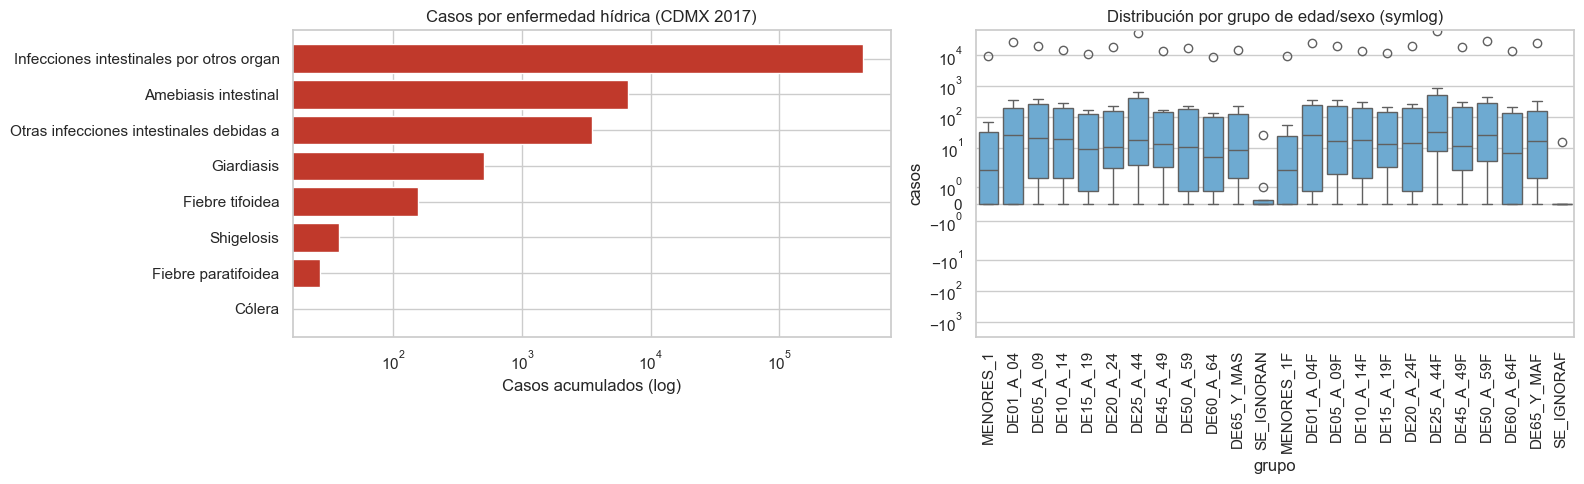

In [14]:
# Visual: barras de casos por enfermedad y boxplot de distribución por grupo de edad
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras (escala log porque los rangos van de 20 a >400 000)
df_orden = df_morbi_cdmx.sort_values("ACUMULADO", ascending=False)
axes[0].barh(df_orden["DES_DIAGNO"].str.slice(0, 40), df_orden["ACUMULADO"], color="#c0392b")
axes[0].set_xscale("log")
axes[0].set_xlabel("Casos acumulados (log)")
axes[0].set_title("Casos por enfermedad hídrica (CDMX 2017)")
axes[0].invert_yaxis()

# Boxplot edad
df_long = df_morbi_cdmx.melt(id_vars=["DES_DIAGNO"],
                              value_vars=COLS_EDAD_AMBOS + COLS_EDAD_F,
                              var_name="grupo", value_name="casos")
sns.boxplot(data=df_long, x="grupo", y="casos", ax=axes[1], color="#5dade2")
axes[1].set_yscale("symlog")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
axes[1].set_title("Distribución por grupo de edad/sexo (symlog)")
plt.tight_layout()
plt.show()

#### Score DAMA — Morbilidad

In [15]:
SCORECARD["morbilidad_ssa"]["Completitud"]  = score_completitud(df_morbi_cdmx, COLS_BASE + COLS_EDAD_AMBOS + COLS_EDAD_F)
SCORECARD["morbilidad_ssa"]["Validez"]      = 100.0 if neg == 0 else round(100 * (1 - neg / df_morbi_cdmx.size), 2)
SCORECARD["morbilidad_ssa"]["Unicidad"]     = round(100 * (1 - dup_logicos / max(len(df_morbi_cdmx), 1)), 2)
SCORECARD["morbilidad_ssa"]["Consistencia"] = round(mejor_pct, 2)
SCORECARD["morbilidad_ssa"]["Puntualidad"]  = np.nan  # no aplica (anuario)
SCORECARD["morbilidad_ssa"]["Integridad"]   = np.nan  # se calcula en sec. 6 (cruzamiento)
print({k: v for k, v in SCORECARD["morbilidad_ssa"].items()})

{'Completitud': 100.0, 'Validez': 100.0, 'Unicidad': 100.0, 'Consistencia': 100.0, 'Puntualidad': nan, 'Integridad': nan}


### 5.2 Censo INEGI ITER 2020

Censo de Población y Vivienda 2020 a nivel localidad. Conservamos el subset CDMX (16 alcaldías × ~1500 localidades) y las variables relevantes para el proyecto: identificación geográfica, demografía agregada y agua/saneamiento.

**Riesgo conocido:** INEGI publica filas de **totales** (`LOC == 0`) y **localidades de dos dígitos especiales** (`LOC == 9998`, `LOC == 9999` para zonas confidenciales). En el perfilado **no las quitamos**, pero las contamos para que la limpieza pueda decidir.

In [47]:
# Carga sin transformar el dataframe original del inventario
df_iter = pd.read_csv(RUTAS["inegi_iter"], encoding="utf-8-sig", low_memory=False,
                       na_values=MISSING_CODES["INEGI"])

# Normalización ligera para subset (no se persiste)
df_iter["ENTIDAD"] = pd.to_numeric(df_iter["ENTIDAD"], errors="coerce")
df_iter_cdmx = df_iter[df_iter["ENTIDAD"] == 9].copy()
print(f"Filas CDMX (todas): {len(df_iter_cdmx):,}")

# Conteo de filas especiales
n_totales = (df_iter_cdmx["LOC"] == 0).sum()
n_confidencial = df_iter_cdmx["LOC"].isin([9998, 9999]).sum()
print(f"  · Filas de TOTALES (LOC=0): {n_totales}")
print(f"  · Filas confidenciales (LOC=9998/9999): {n_confidencial}")
print(f"  · Localidades 'reales': {len(df_iter_cdmx) - n_totales - n_confidencial:,}")

# Columnas relevantes para nuestro proyecto
COLS_BASE_INEGI = ["ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "LOC", "NOM_LOC",
                   "LONGITUD", "LATITUD", "ALTITUD", "TAMLOC"]
COLS_POB_INEGI = ["POBTOT", "POB0_14", "POB15_64", "POB65_MAS"]
COLS_VIV_INEGI = ["VIVTOT", "TVIVPARHAB", "VPH_AGUADV", "VPH_AGUAFV",
                  "VPH_TINACO", "VPH_CISTER", "VPH_DRENAJ", "VPH_NODREN",
                  "VPH_C_SERV", "VPH_EXCSA"]
COLS_REL_INEGI = COLS_BASE_INEGI + COLS_POB_INEGI + COLS_VIV_INEGI

# Coerción a numérico (sólo en la copia de subset, para perfilar)
#for col in COLS_POB_INEGI + COLS_VIV_INEGI:
    #df_iter_cdmx[col] = pd.to_numeric(df_iter_cdmx[col], errors="coerce")

# Coerción a numérico (sólo en la copia de subset, para perfilar)
COLS_NUM_INEGI = COLS_POB_INEGI + COLS_VIV_INEGI + ["LATITUD", "LONGITUD", "ALTITUD"]
for col in COLS_NUM_INEGI:
    df_iter_cdmx[col] = pd.to_numeric(df_iter_cdmx[col], errors="coerce")

Filas CDMX (todas): 666
  · Filas de TOTALES (LOC=0): 17
  · Filas confidenciales (LOC=9998/9999): 15
  · Localidades 'reales': 634


#### Completitud, Validez, Unicidad

In [48]:
header("INEGI — Completitud, Validez, Unicidad", level=2)

# 1) Completitud (sólo localidades reales)
df_loc = df_iter_cdmx[(df_iter_cdmx["LOC"] != 0) & (~df_iter_cdmx["LOC"].isin([9998, 9999]))]
nulos_inegi = perfil_completitud(df_loc, COLS_REL_INEGI)
print(f"Localidades reales perfiladas: {len(df_loc):,}")
print(f"Columnas con nulos > 0%:")
print(nulos_inegi[nulos_inegi > 0].sort_values(ascending=False).head(15))

# 2) Validez geográfica (bounding box correcto CDMX)
mask_lat_invalida = (df_loc["LATITUD"] < CDMX_BBOX["lat_min"]) | (df_loc["LATITUD"] > CDMX_BBOX["lat_max"])
mask_lon_invalida = (df_loc["LONGITUD"] < CDMX_BBOX["lon_min"]) | (df_loc["LONGITUD"] > CDMX_BBOX["lon_max"])
n_geo_invalido = (mask_lat_invalida | mask_lon_invalida).sum()
print(f"\nValidez geográfica:")
print(f"  Localidades fuera del bounding box CDMX: {n_geo_invalido}")

# 3) Validez de rango (ningún conteo puede ser negativo)
neg_inegi = (df_loc[COLS_POB_INEGI + COLS_VIV_INEGI] < 0).sum().sum()
print(f"  Conteos negativos: {neg_inegi}")

# 4) Unicidad por clave geográfica compuesta
clave_geo = (df_loc["ENTIDAD"].astype(str).str.zfill(2)
             + df_loc["MUN"].astype(str).str.zfill(3)
             + df_loc["LOC"].astype(str).str.zfill(4))
dup_geo = clave_geo.duplicated().sum()
print(f"\nUnicidad: claves geográficas duplicadas (ENT+MUN+LOC): {dup_geo}")


----------------------------------------------------------------------
INEGI — Completitud, Validez, Unicidad
----------------------------------------------------------------------
Localidades reales perfiladas: 634
Columnas con nulos > 0%:
LONGITUD      100.00
LATITUD       100.00
POB0_14        22.08
POB15_64       22.08
POB65_MAS      22.08
TVIVPARHAB     22.08
VPH_AGUADV     22.08
VPH_AGUAFV     22.08
VPH_TINACO     22.08
VPH_CISTER     22.08
VPH_DRENAJ     22.08
VPH_NODREN     22.08
VPH_C_SERV     22.08
VPH_EXCSA      22.08
dtype: float64

Validez geográfica:
  Localidades fuera del bounding box CDMX: 0
  Conteos negativos: 0

Unicidad: claves geográficas duplicadas (ENT+MUN+LOC): 0


#### Consistencia (reglas de negocio del Censo)

In [49]:
header("INEGI — Consistencia", level=2)

reglas_inegi = []

# Regla 1: TVIVPARHAB <= VIVTOT
m1 = (df_loc["TVIVPARHAB"] > df_loc["VIVTOT"])
reglas_inegi.append(("TVIVPARHAB ≤ VIVTOT", int(m1.sum()), len(df_loc)))

# Regla 2: VPH_AGUADV <= TVIVPARHAB
m2 = (df_loc["VPH_AGUADV"] > df_loc["TVIVPARHAB"])
reglas_inegi.append(("VPH_AGUADV ≤ TVIVPARHAB", int(m2.sum()), len(df_loc)))

# Regla 3: POB0_14 + POB15_64 + POB65_MAS <= POBTOT  (existen no especificados)
suma_pob = df_loc["POB0_14"] + df_loc["POB15_64"] + df_loc["POB65_MAS"]
m3 = (suma_pob > df_loc["POBTOT"])
reglas_inegi.append(("Σ rangos macro de edad ≤ POBTOT", int(m3.sum()), len(df_loc)))

# Regla 4: VPH_DRENAJ + VPH_NODREN <= TVIVPARHAB
m4 = (df_loc["VPH_DRENAJ"] + df_loc["VPH_NODREN"]) > df_loc["TVIVPARHAB"]
reglas_inegi.append(("VPH_DRENAJ + VPH_NODREN ≤ TVIVPARHAB", int(m4.sum()), len(df_loc)))

df_reglas_inegi = pd.DataFrame(reglas_inegi, columns=["regla", "n_violaciones", "n_filas"])
df_reglas_inegi["pct_violaciones"] = (df_reglas_inegi["n_violaciones"] / df_reglas_inegi["n_filas"] * 100).round(2)
display(df_reglas_inegi)
score_consistencia_inegi = round(100 * (1 - df_reglas_inegi["n_violaciones"].sum()
                                       / max(df_reglas_inegi["n_filas"].sum(), 1)), 2)


----------------------------------------------------------------------
INEGI — Consistencia
----------------------------------------------------------------------


,regla,n_violaciones,n_filas,pct_violaciones
0,TVIVPARHAB ≤ VIVTOT,0,634,0.0
1,VPH_AGUADV ≤ TVIVPARHAB,0,634,0.0
2,Σ rangos macro de edad ≤ POBTOT,0,634,0.0
3,VPH_DRENAJ + VPH_NODREN ≤ TVIVPARHAB,0,634,0.0


#### Distribuciones de infraestructura hídrica

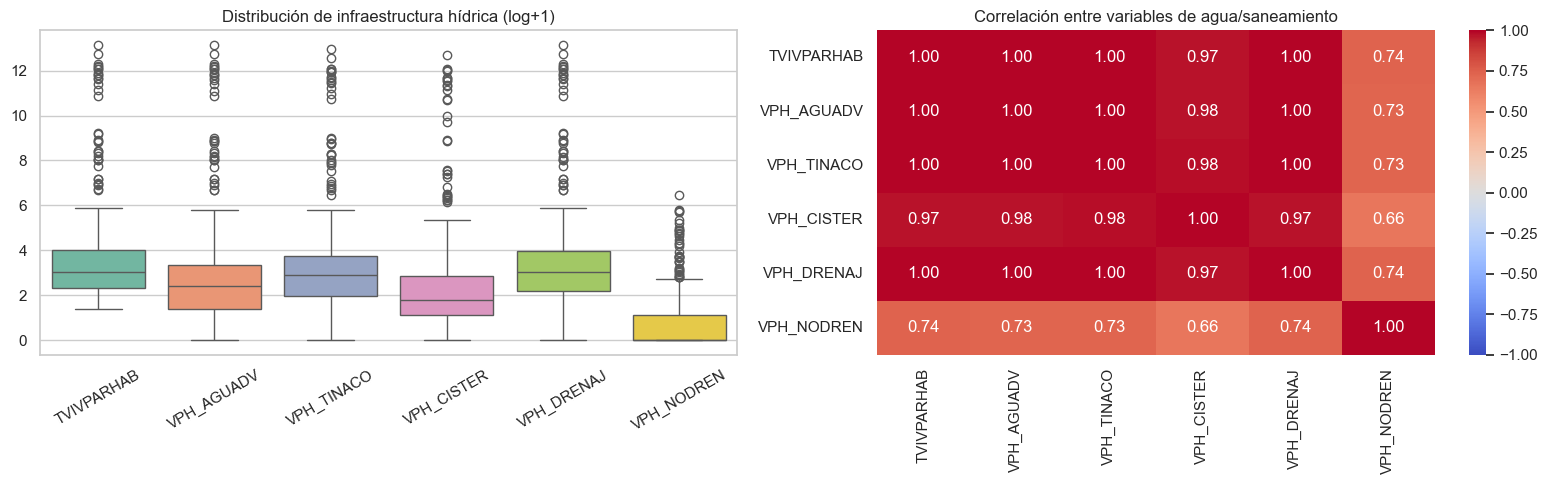

In [50]:
# Boxplot infraestructura (log+1) y heatmap de correlación en una sola figura
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vars_box = ["TVIVPARHAB", "VPH_AGUADV", "VPH_TINACO", "VPH_CISTER", "VPH_DRENAJ", "VPH_NODREN"]
sns.boxplot(data=np.log1p(df_loc[vars_box]), ax=axes[0], palette="Set2")
axes[0].set_title("Distribución de infraestructura hídrica (log+1)")
axes[0].set_xticklabels(vars_box, rotation=30)

corr_inegi = df_loc[vars_box].corr()
sns.heatmap(corr_inegi, annot=True, cmap="coolwarm", fmt=".2f",
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlación entre variables de agua/saneamiento")

plt.tight_layout()
plt.show()

In [51]:
SCORECARD["inegi_iter"]["Completitud"]  = score_completitud(df_loc, COLS_REL_INEGI)
SCORECARD["inegi_iter"]["Validez"]      = round(100 * (1 - (n_geo_invalido + neg_inegi) / max(len(df_loc) * 2, 1)), 2)
SCORECARD["inegi_iter"]["Unicidad"]     = round(100 * (1 - dup_geo / max(len(df_loc), 1)), 2)
SCORECARD["inegi_iter"]["Consistencia"] = score_consistencia_inegi
SCORECARD["inegi_iter"]["Puntualidad"]  = np.nan
SCORECARD["inegi_iter"]["Integridad"]   = np.nan
print({k: v for k, v in SCORECARD["inegi_iter"].items()})

{'Completitud': 80.63, 'Integridad': nan, 'Validez': 100.0, 'Unicidad': 100.0, 'Consistencia': 100.0, 'Puntualidad': nan}


### 5.3 CONEVAL · Pobreza por grupos de edad

Medición de pobreza multidimensional 2010‑2020 con desagregación por alcaldía y grupo poblacional. **Trampa estadística clave:** CONEVAL codifica los valores no calculables como `-999.0` (no como `NaN`); en el notebook original se identifica correctamente y aquí lo formalizamos vía `MISSING_CODES`.

In [21]:
# Carga con códigos de missing CONEVAL convertidos a NaN
df_pobreza = pd.read_csv(RUTAS["coneval_pobreza"], encoding="utf-8")
df_pobreza["clave_entidad"] = pd.to_numeric(df_pobreza["clave_entidad"], errors="coerce")
df_pobreza_cdmx = df_pobreza[df_pobreza["clave_entidad"] == 9].copy()

COLS_PCT_CONEVAL = [
    "pobreza_porcentaje",
    "carencia_servicios_basicos_vivienda_porcentaje",
    "carencia_calidad_espacios_vivienda_porcentaje",
    "ingreso_inferior_a_lpi_porcentaje",
]

# Aplicar el código de missing -999 -> NaN (sólo en la copia)
for c in COLS_PCT_CONEVAL:
    df_pobreza_cdmx[c] = df_pobreza_cdmx[c].replace(-999.0, np.nan)

print(f"Registros CDMX en CONEVAL: {len(df_pobreza_cdmx):,}")
print(f"Periodos: {sorted(df_pobreza_cdmx['periodo'].dropna().unique())}")
print(f"Grupos: {df_pobreza_cdmx['grupo'].unique().tolist()}")

Registros CDMX en CONEVAL: 192
Periodos: ['2010-01-01', '2015-01-01', '2020-01-01']
Grupos: ['Niñas, niños y adolescentes (0 a 17 años)', 'Jóvenes (18 a 29 años)', 'Adultos (30 a 64 años)', 'Adultos mayores (65 o más años)']


#### Completitud · Validez · Unicidad · Consistencia

In [22]:
header("CONEVAL — Completitud", level=2)
nulos_coneval = perfil_completitud(df_pobreza_cdmx, COLS_PCT_CONEVAL)
display(nulos_coneval.to_frame("pct_nulos").sort_values("pct_nulos", ascending=False))

header("CONEVAL — Validez", level=2)
df_pobreza_cdmx["anio"] = pd.to_datetime(df_pobreza_cdmx["periodo"], errors="coerce").dt.year
porc_invalidos = ((df_pobreza_cdmx[COLS_PCT_CONEVAL] > 100) | (df_pobreza_cdmx[COLS_PCT_CONEVAL] < 0)).sum().sum()
print(f"Porcentajes fuera del rango 0–100: {porc_invalidos}")
print(f"Años detectados: {sorted(df_pobreza_cdmx['anio'].dropna().unique())}")

header("CONEVAL — Unicidad", level=2)
clave_logica = ["clave_municipio", "anio", "grupo"]
dup_coneval = df_pobreza_cdmx.duplicated(subset=clave_logica).sum()
print(f"Duplicados lógicos (alcaldía+año+grupo): {dup_coneval}")

header("CONEVAL — Consistencia (regla institucional CONEVAL)", level=2)
# Regla CONEVAL: pobreza ≤ ingreso_inferior_a_lpi (ser pobre requiere bajo ingreso + ≥1 carencia social;
# bajo ingreso es por construcción una cota superior).
mask_coneval = ((df_pobreza_cdmx["pobreza_porcentaje"].notna()) &
                (df_pobreza_cdmx["ingreso_inferior_a_lpi_porcentaje"].notna()))
n_violaciones = (df_pobreza_cdmx.loc[mask_coneval, "pobreza_porcentaje"]
                 > df_pobreza_cdmx.loc[mask_coneval, "ingreso_inferior_a_lpi_porcentaje"]).sum()
n_eval = mask_coneval.sum()
print(f"Regla pobreza ≤ ingreso<LPI:")
print(f"  Filas evaluables: {n_eval:,}")
print(f"  Violaciones: {n_violaciones} ({n_violaciones/max(n_eval,1)*100:.2f}%)")


----------------------------------------------------------------------
CONEVAL — Completitud
----------------------------------------------------------------------


,pct_nulos
carencia_servicios_basicos_vivienda_porcentaje,80.21
carencia_calidad_espacios_vivienda_porcentaje,19.27
pobreza_porcentaje,3.65
ingreso_inferior_a_lpi_porcentaje,2.60



----------------------------------------------------------------------
CONEVAL — Validez
----------------------------------------------------------------------
Porcentajes fuera del rango 0–100: 2
Años detectados: [2010, 2015, 2020]

----------------------------------------------------------------------
CONEVAL — Unicidad
----------------------------------------------------------------------
Duplicados lógicos (alcaldía+año+grupo): 0

----------------------------------------------------------------------
CONEVAL — Consistencia (regla institucional CONEVAL)
----------------------------------------------------------------------
Regla pobreza ≤ ingreso<LPI:
  Filas evaluables: 184
  Violaciones: 0 (0.00%)


In [23]:
SCORECARD["coneval_pobreza"]["Completitud"]  = score_completitud(df_pobreza_cdmx, COLS_PCT_CONEVAL)
SCORECARD["coneval_pobreza"]["Validez"]      = 100.0 if porc_invalidos == 0 else round(100 * (1 - porc_invalidos / df_pobreza_cdmx[COLS_PCT_CONEVAL].size), 2)
SCORECARD["coneval_pobreza"]["Unicidad"]     = round(100 * (1 - dup_coneval / max(len(df_pobreza_cdmx), 1)), 2)
SCORECARD["coneval_pobreza"]["Consistencia"] = round(100 * (1 - n_violaciones / max(n_eval, 1)), 2)
SCORECARD["coneval_pobreza"]["Puntualidad"]  = np.nan
SCORECARD["coneval_pobreza"]["Integridad"]   = np.nan
print({k: v for k, v in SCORECARD["coneval_pobreza"].items()})

{'Completitud': 73.57, 'Validez': 99.74, 'Unicidad': 100.0, 'Consistencia': 100.0, 'Puntualidad': nan, 'Integridad': nan}


### 5.4 Catálogo SEPOMEX

Catálogo oficial de colonias y códigos postales de la CDMX. Es el **eje de fusión** para SACMEX (que reporta por alcaldía+colonia) e idealmente para conectar con INEGI. Se profila la unicidad y la consistencia jerárquica (CP → alcaldía → estado).

In [24]:
df_sepomex = pd.read_csv(RUTAS["sepomex"], encoding="utf-8-sig")
print(f"Registros: {len(df_sepomex):,}")
print(f"Estados únicos: {df_sepomex['nom_estado'].nunique()}")
print(f"Alcaldías únicas: {df_sepomex['nom_alcaldia'].nunique()}")
print(f"Colonias únicas: {df_sepomex['nom_colonia'].nunique()}")
print(f"Códigos postales únicos: {df_sepomex['codigo_postal'].nunique()}")

# Completitud
print("\nCompletitud:")
print(perfil_completitud(df_sepomex))

# Validez del CP (debe ser 5 dígitos numéricos en CDMX comienzan con 0)
n_cp_invalido = (~df_sepomex["codigo_postal"].astype(str).str.match(r"^\d{5}$")).sum()
print(f"\nCP con formato no válido (no 5 dígitos): {n_cp_invalido}")

# Unicidad: una colonia puede compartirse entre alcaldías; lo que NO debe duplicarse es (alcaldía, colonia, CP)
dup_pk = df_sepomex.duplicated(subset=["cve_alcaldia", "nom_colonia", "codigo_postal"]).sum()
print(f"Duplicados (alcaldía+colonia+CP): {dup_pk}")

# Consistencia: ¿un CP puede pertenecer a >1 alcaldía? Sí, en realidad sucede; pero ¿uno a >1 estado?
cp_multi_estado = df_sepomex.groupby("codigo_postal")["nom_estado"].nunique()
print(f"CP que aparecen en más de un estado: {(cp_multi_estado > 1).sum()}")

Registros: 1,526
Estados únicos: 1
Alcaldías únicas: 16
Colonias únicas: 1382
Códigos postales únicos: 1110

Completitud:
nom_estado       0.0
cve_estado       0.0
nom_alcaldia     0.0
cve_alcaldia     0.0
nom_colonia      0.0
codigo_postal    0.0
dtype: float64

CP con formato no válido (no 5 dígitos): 956
Duplicados (alcaldía+colonia+CP): 0
CP que aparecen en más de un estado: 0


In [25]:
SCORECARD["sepomex"]["Completitud"]  = score_completitud(df_sepomex)
SCORECARD["sepomex"]["Validez"]      = round(100 * (1 - n_cp_invalido / max(len(df_sepomex), 1)), 2)
SCORECARD["sepomex"]["Unicidad"]     = round(100 * (1 - dup_pk / max(len(df_sepomex), 1)), 2)
SCORECARD["sepomex"]["Consistencia"] = round(100 * (1 - (cp_multi_estado > 1).sum() / max(df_sepomex["codigo_postal"].nunique(), 1)), 2)
SCORECARD["sepomex"]["Puntualidad"]  = np.nan
SCORECARD["sepomex"]["Integridad"]   = np.nan
print({k: v for k, v in SCORECARD["sepomex"].items()})

{'Completitud': 100.0, 'Validez': 37.35, 'Unicidad': 100.0, 'Consistencia': 100.0, 'Puntualidad': nan, 'Integridad': nan}


### 5.5 SACMEX · Reportes de fugas (Puntualidad profunda)

El dataset más grande del proyecto (>300 K registros) y el único con dimensión **temporal** rica. El notebook original le dedicaba 7 líneas; aquí cubrimos:

1. **Completitud** por columna y patrón temporal.
2. **Validez de fechas:** parseo, formatos, fechas anómalas (futuras, pre‑2018).
3. **Validez geográfica** con el bounding box CDMX correcto.
4. **Unicidad** por folio.
5. **Consistencia / Puntualidad:** lag entre `fecha_registro_incidente` y `fecha_reporte` — métrica clave del Problema 3 del README.
6. **Frecuencias categóricas:** clasificacion, reporte (texto libre), medio_recepcion.
7. **Cobertura territorial** (alcaldía/colonia) cruzada con SEPOMEX.

> **Alerta de scope:** el README declara el uso de SACMEX 2018‑2024, pero el repositorio sólo contiene `reportes_agua_2024_01.csv` (un mes). El histórico debe agregarse antes de `fusion.ipynb`.

In [26]:
df_sacmex = pd.read_csv(RUTAS["sacmex_reportes"], encoding="utf-8", low_memory=False)
print(f"Registros: {len(df_sacmex):,}")
print(f"Columnas: {df_sacmex.columns.tolist()}")
print("\nMuestra:")
display(df_sacmex.head(3))

Registros: 313,756
Columnas: ['folio_incidente', 'fecha_registro_incidente', 'id_reporte', 'fecha_reporte', 'hora_reporte', 'clasificacion', 'reporte', 'medio_recepcion', 'alcaldia_catalogo', 'colonia_catalogo', 'longitud', 'latitud']

Muestra:


,folio_incidente,fecha_registro_incidente,id_reporte,fecha_reporte,hora_reporte,clasificacion,reporte,medio_recepcion,alcaldia_catalogo,colonia_catalogo,longitud,latitud
0,I-20220101-0001,2022-01-02,R-20220101-0105,2022-01-01,18:33:08,Agua Potable,Fuga,Ciudadano (Call Center),Coyoacán,Cuadrante De San Francisco,-99.168273,19.341800
1,I-20220101-0002,2022-01-02,R-20220101-0106,2022-01-01,18:36:38,Drenaje,Drenaje Obstruido,Ciudadano (Call Center),Xochimilco,San Lorenzo La Cebada,-99.115645,19.286181
2,I-20220101-0003,2022-01-02,R-20220101-0103,2022-01-01,18:12:39,Agua Potable,Fuga,Ciudadano (Call Center),Tláhuac,Barrio Santiago Norte Del Pueblo Santiago Zapo...,-99.030287,19.300514


#### Completitud y validez de fechas

In [27]:
header("SACMEX — Completitud", level=2)
n = len(df_sacmex)
nulos_pct_sacmex = (df_sacmex.isnull().mean() * 100).round(2)
print(f"Total registros: {n:,}\n")
print("% nulos por columna:")
display(nulos_pct_sacmex.sort_values(ascending=False).to_frame("pct_nulos"))

header("SACMEX — Validez de fechas", level=2)
# Parseo defensivo (sin persistir en el original)
fecha_reg = pd.to_datetime(df_sacmex["fecha_registro_incidente"], errors="coerce", dayfirst=True)
fecha_rep = pd.to_datetime(df_sacmex["fecha_reporte"], errors="coerce", dayfirst=True)

n_invalido_reg = fecha_reg.isnull().sum() - df_sacmex["fecha_registro_incidente"].isnull().sum()
n_invalido_rep = fecha_rep.isnull().sum() - df_sacmex["fecha_reporte"].isnull().sum()
print(f"Fechas no parseables (fecha_registro_incidente): {n_invalido_reg}")
print(f"Fechas no parseables (fecha_reporte):           {n_invalido_rep}")

# Anomalías temporales
hoy = pd.Timestamp.today()
n_futuras = (fecha_rep > hoy).sum()
n_pre2018 = (fecha_rep < pd.Timestamp("2018-01-01")).sum()
n_post2024 = (fecha_rep > pd.Timestamp("2024-12-31")).sum()
print(f"\nFechas de reporte anómalas:")
print(f"  Futuras (> hoy):                {n_futuras:,}")
print(f"  Anteriores a 2018-01-01:        {n_pre2018:,}")
print(f"  Posteriores a 2024-12-31:       {n_post2024:,}")
print(f"  Rango observado: {fecha_rep.min()}  →  {fecha_rep.max()}")


----------------------------------------------------------------------
SACMEX — Completitud
----------------------------------------------------------------------
Total registros: 313,756

% nulos por columna:


,pct_nulos
colonia_catalogo,1.52
alcaldia_catalogo,0.30
folio_incidente,0.00
fecha_registro_incidente,0.00
id_reporte,0.00
fecha_reporte,0.00
hora_reporte,0.00
clasificacion,0.00
reporte,0.00
medio_recepcion,0.00



----------------------------------------------------------------------
SACMEX — Validez de fechas
----------------------------------------------------------------------
Fechas no parseables (fecha_registro_incidente): 189123
Fechas no parseables (fecha_reporte):           189657

Fechas de reporte anómalas:
  Futuras (> hoy):                0
  Anteriores a 2018-01-01:        0
  Posteriores a 2024-12-31:       0
  Rango observado: 2022-01-01 00:00:00  →  2024-12-01 00:00:00


#### Puntualidad: lag entre incidente y registro


----------------------------------------------------------------------
SACMEX — Puntualidad (lag incidente → reporte)
----------------------------------------------------------------------
Estadísticos del lag (días):
count    118962.00
mean          0.17
std          30.03
min        -333.00
5%          -31.00
25%           0.00
50%           0.00
75%           0.00
95%          28.00
99%         123.00
max         661.00
dtype: float64

Lag < 0 (reporte antes que incidente, imposible): 14,654
Lag > 30 días (reporte muy tardío):                4,946

% de reportes puntuales (lag entre 0 y 1 día): 82.51%  (98,156/118,962)


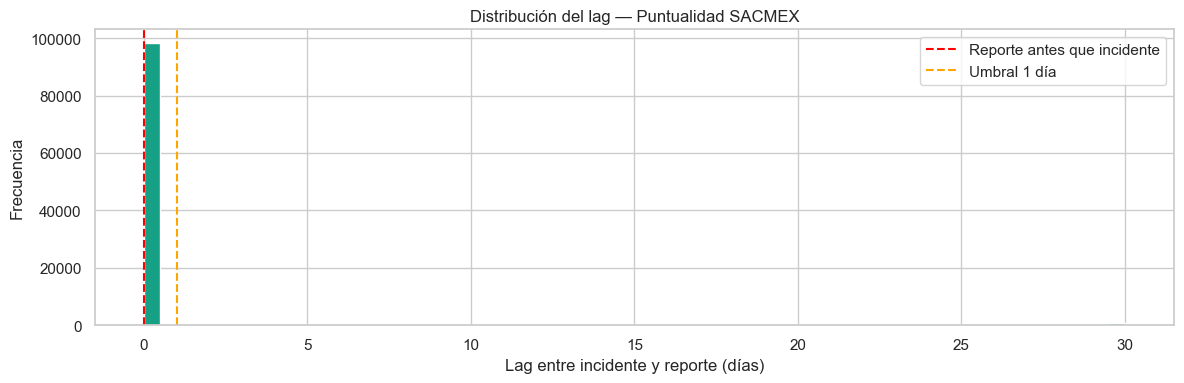

In [28]:
header("SACMEX — Puntualidad (lag incidente → reporte)", level=2)

lag = (fecha_rep - fecha_reg).dt.total_seconds() / 86400  # días
print("Estadísticos del lag (días):")
print(lag.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

n_lag_neg = (lag < 0).sum()
n_lag_largo = (lag > 30).sum()
print(f"\nLag < 0 (reporte antes que incidente, imposible): {n_lag_neg:,}")
print(f"Lag > 30 días (reporte muy tardío):                {n_lag_largo:,}")

# % de reportes "puntuales" (lag <= 1 día)
n_evaluables = lag.notna().sum()
n_puntuales = (lag.between(0, 1)).sum()
pct_puntuales = round(100 * n_puntuales / max(n_evaluables, 1), 2)
print(f"\n% de reportes puntuales (lag entre 0 y 1 día): {pct_puntuales}%  ({n_puntuales:,}/{n_evaluables:,})")

# Visualización
fig, ax = plt.subplots(figsize=(12, 4))
lag_plot = lag[(lag >= -1) & (lag <= 30)]
ax.hist(lag_plot, bins=60, color="#16a085", edgecolor="white")
ax.axvline(0, linestyle="--", color="red", label="Reporte antes que incidente")
ax.axvline(1, linestyle="--", color="orange", label="Umbral 1 día")
ax.set_xlabel("Lag entre incidente y reporte (días)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del lag — Puntualidad SACMEX")
ax.legend()
plt.tight_layout()
plt.show()

#### Distribución temporal y por canal de recepción

In [29]:
# Mes, día de semana, hora del reporte
mes = fecha_rep.dt.month
dia_sem = fecha_rep.dt.day_name()
hora = pd.to_datetime(df_sacmex["hora_reporte"], errors="coerce", format="%H:%M:%S").dt.hour

print("Distribución por mes (de fecha_reporte):")
print(mes.value_counts().sort_index())
print("\nDistribución por día de la semana:")
print(dia_sem.value_counts())
print("\nDistribución por hora (top 5):")
print(hora.value_counts().sort_index().head(24))

# Frecuencias categóricas
header("SACMEX — Categorías", level=3)
print("\nMedios de recepción:")
print(df_sacmex["medio_recepcion"].value_counts(dropna=False).head(10))
print("\nClasificaciones:")
print(df_sacmex["clasificacion"].value_counts(dropna=False).head(10))
print("\nTop 10 reportes (texto libre, conteo de duplicados textuales):")
print(df_sacmex["reporte"].value_counts(dropna=False).head(10))

Distribución por mes (de fecha_reporte):
fecha_reporte
1.0      9622
2.0      9778
3.0      9789
4.0     10975
5.0     10415
6.0     11089
7.0     10972
8.0     10332
9.0     10323
10.0    10592
11.0    10525
12.0     9687
Name: count, dtype: int64

Distribución por día de la semana:
fecha_reporte
Sunday       18969
Thursday     18197
Friday       18190
Monday       17944
Saturday     17171
Wednesday    16909
Tuesday      16719
Name: count, dtype: int64

Distribución por hora (top 5):
hora_reporte
0      1287
1       640
2       363
3       251
4       250
5       405
6      1420
7      6787
8     26959
9     32915
10    28784
11    30463
12    29946
13    27099
14    25793
15    21052
16    18638
17    16169
18    13712
19    11434
20     8708
21     5248
22     3287
23     2146
Name: count, dtype: int64

······································································
SACMEX — Categorías
······································································

Medios de recepción

#### Validez geográfica y unicidad

In [30]:
header("SACMEX — Validez geográfica", level=2)
mask_lat = (df_sacmex["latitud"] < CDMX_BBOX["lat_min"]) | (df_sacmex["latitud"] > CDMX_BBOX["lat_max"])
mask_lon = (df_sacmex["longitud"] < CDMX_BBOX["lon_min"]) | (df_sacmex["longitud"] > CDMX_BBOX["lon_max"])
mask_geo_nan = df_sacmex[["latitud", "longitud"]].isnull().any(axis=1)
n_fuera_bbox = ((mask_lat | mask_lon) & ~mask_geo_nan).sum()
n_geo_nulo = mask_geo_nan.sum()
print(f"Registros sin coordenadas: {n_geo_nulo:,}")
print(f"Coordenadas fuera del bounding box CDMX: {n_fuera_bbox:,}")

header("SACMEX — Unicidad", level=2)
dup_folio = df_sacmex.duplicated(subset=["folio_incidente"]).sum()
dup_id = df_sacmex.duplicated(subset=["id_reporte"]).sum()
dup_full = df_sacmex.duplicated().sum()
print(f"Duplicados por folio_incidente: {dup_folio:,}")
print(f"Duplicados por id_reporte:      {dup_id:,}")
print(f"Duplicados por fila completa:   {dup_full:,}")


----------------------------------------------------------------------
SACMEX — Validez geográfica
----------------------------------------------------------------------
Registros sin coordenadas: 0
Coordenadas fuera del bounding box CDMX: 166

----------------------------------------------------------------------
SACMEX — Unicidad
----------------------------------------------------------------------
Duplicados por folio_incidente: 58,610
Duplicados por id_reporte:      12,729
Duplicados por fila completa:   12,729


#### Cobertura territorial — Cruce con SEPOMEX

Cuántas alcaldías/colonias reportadas por SACMEX existen en el catálogo oficial. Es **integridad referencial** sobre la dimensión geográfica.

In [31]:
# Normalizamos sólo para comparar (no se persiste)
sac_alc = normalizar_texto(df_sacmex["alcaldia_catalogo"])
sac_col = normalizar_texto(df_sacmex["colonia_catalogo"])
sep_alc = normalizar_texto(df_sepomex["nom_alcaldia"])
sep_col = normalizar_texto(df_sepomex["nom_colonia"])

# Alcaldías
alcaldias_sac = set(sac_alc.unique()) - {""}
alcaldias_sep = set(sep_alc.unique()) - {""}
solo_sac = alcaldias_sac - alcaldias_sep
solo_sep = alcaldias_sep - alcaldias_sac
print(f"Alcaldías SACMEX: {len(alcaldias_sac)} | SEPOMEX: {len(alcaldias_sep)}")
print(f"  En SACMEX pero NO en SEPOMEX: {len(solo_sac)} → {sorted(solo_sac)[:10]}")
print(f"  En SEPOMEX pero NO en SACMEX: {len(solo_sep)} → {sorted(solo_sep)[:10]}")

# Pares (alcaldía, colonia)
pairs_sac = set(zip(sac_alc, sac_col))
pairs_sep = set(zip(sep_alc, sep_col))
pairs_huerfanos = pairs_sac - pairs_sep
n_huerfanos_pairs = len(pairs_huerfanos)
n_filas_huerfanas = (~pd.Series(list(zip(sac_alc, sac_col))).isin(pairs_sep)).sum()
print(f"\nPares (alcaldía, colonia) en SACMEX sin match en SEPOMEX: {n_huerfanos_pairs:,}")
print(f"Filas SACMEX afectadas: {n_filas_huerfanas:,} ({100*n_filas_huerfanas/len(df_sacmex):.2f}%)")

Alcaldías SACMEX: 16 | SEPOMEX: 16
  En SACMEX pero NO en SEPOMEX: 0 → []
  En SEPOMEX pero NO en SACMEX: 0 → []

Pares (alcaldía, colonia) en SACMEX sin match en SEPOMEX: 488
Filas SACMEX afectadas: 60,843 (19.39%)


In [ ]:
# Score SACMEX
SCORECARD["sacmex_reportes"]["Completitud"]  = score_completitud(df_sacmex)
SCORECARD["sacmex_reportes"]["Validez"]      = round(100 * (1 - (n_invalido_reg + n_invalido_rep + n_fuera_bbox + n_futuras + n_pre2018) / max(len(df_sacmex) * 5, 1)), 2)
SCORECARD["sacmex_reportes"]["Unicidad"]     = round(100 * (1 - dup_folio / max(len(df_sacmex), 1)), 2)
SCORECARD["sacmex_reportes"]["Consistencia"] = round(100 * (1 - n_lag_neg / max(n_evaluables, 1)), 2)
SCORECARD["sacmex_reportes"]["Puntualidad"]  = pct_puntuales
SCORECARD["sacmex_reportes"]["Integridad"]   = round(100 * (1 - n_filas_huerfanas / max(len(df_sacmex), 1)), 2)
print({k: v for k, v in SCORECARD["sacmex_reportes"].items()})

### 5.6 CONAGUA · Catálogo de Sitios de monitoreo

Catálogo nacional de sitios donde CONAGUA monitorea calidad del agua. Se revisa la validez geográfica y la unicidad de la `CLAVE SITIO`. **No se aplica filtro CDMX aquí** porque el catálogo nacional sirve también para sitios *abastecedores* de la CDMX (Cutzamala, Lerma) que están fuera del polígono.

In [8]:
df_sitios = pd.read_csv(RUTAS["conagua_sitios"], encoding="utf-8-sig", low_memory=False)
print(f"Registros: {len(df_sitios):,}")
print(f"Columnas: {df_sitios.columns.tolist()}")

# Completitud
header("CONAGUA Sitios — Completitud", level=2)
nulos_sitios = perfil_completitud(df_sitios)
display(nulos_sitios.sort_values(ascending=False).to_frame("pct_nulos"))

# Validez de coordenadas (a nivel global, deben caer en territorio mexicano aprox.)
df_sitios["LATITUD"]  = pd.to_numeric(df_sitios["LATITUD"],  errors="coerce")
df_sitios["LONGITUD"] = pd.to_numeric(df_sitios["LONGITUD"], errors="coerce")

n_lat_null = df_sitios["LATITUD"].isnull().sum()
n_lon_null = df_sitios["LONGITUD"].isnull().sum()
mask_mx = ((df_sitios["LATITUD"].between(14.5, 32.7)) &
            (df_sitios["LONGITUD"].between(-118.5, -86.5)))
n_fuera_mx = (~mask_mx & df_sitios["LATITUD"].notna() & df_sitios["LONGITUD"].notna()).sum()
print(f"\nValidez geográfica:")
print(f"  Latitud nula:  {n_lat_null:,}")
print(f"  Longitud nula: {n_lon_null:,}")
print(f"  Fuera del bounding box de México: {n_fuera_mx:,}")

# Unicidad
header("CONAGUA Sitios — Unicidad", level=2)
dup_clave = df_sitios.duplicated(subset=["CLAVE SITIO"]).sum()
print(f"CLAVE SITIO duplicadas: {dup_clave:,}")

# Catálogos categóricos
print(f"\nEstados representados: {df_sitios['ESTADO'].nunique()}")
print(f"Tipos de cuerpo de agua:")
print(df_sitios["TIPO DE CUERPO DE AGUA"].value_counts())

Registros: 7,771
Columnas: ['CLAVE SITIO', 'NOMBRE DEL SITIO', 'CUENCA', 'CLAVE ACUÍFERO', 'ACUÍFERO', 'ORGANISMO CUENCA', 'DIRECCIÓN LOCAL', 'ESTADO', 'MUNICIPIO', 'CUERPO DE AGUA', 'TIPO DE CUERPO DE AGUA', 'SUBTIPO CUERPO AGUA', 'LATITUD', 'LONGITUD']

----------------------------------------------------------------------
CONAGUA Sitios — Completitud
----------------------------------------------------------------------


,pct_nulos
CLAVE ACUÍFERO,62.91
ACUÍFERO,62.91
DIRECCIÓN LOCAL,50.97
CUENCA,35.39
CUERPO DE AGUA,0.10
CLAVE SITIO,0.00
NOMBRE DEL SITIO,0.00
ORGANISMO CUENCA,0.00
ESTADO,0.00
MUNICIPIO,0.00



Validez geográfica:
  Latitud nula:  0
  Longitud nula: 0
  Fuera del bounding box de México: 15

----------------------------------------------------------------------
CONAGUA Sitios — Unicidad
----------------------------------------------------------------------
CLAVE SITIO duplicadas: 0

Estados representados: 35
Tipos de cuerpo de agua:
TIPO DE CUERPO DE AGUA
SUBTERRÁNEO                       2789
LÓTICO                            2090
LÉNTICO (HUMEDAL)                  615
COSTERO (HUMEDAL)                  523
LÉNTICO                            518
COSTERO                            422
LÓTICO (HUMEDAL)                   368
LÉNTICO (ESTUDIO ESPECIAL)          77
LÓTICO - COSTERO (HUMEDAL)          74
LÓTICO - COSTERO                    72
LÓTICO (ESTUDIO ESPECIAL)           55
LÉNTICO - COSTERO (HUMEDAL)         54
SUBTERRÁNEO (ESTUDIO ESPECIAL)      47
LÓTICO                              39
LÉNTICO - COSTERO                   10
COSTERO Y SEDIMENTOS                 9
LÉNTICO 

In [9]:
SCORECARD["conagua_sitios"]["Completitud"]  = score_completitud(df_sitios)
SCORECARD["conagua_sitios"]["Validez"]      = round(100 * (1 - (n_lat_null + n_lon_null + n_fuera_mx) / max(len(df_sitios) * 3, 1)), 2)
SCORECARD["conagua_sitios"]["Unicidad"]     = round(100 * (1 - dup_clave / max(len(df_sitios), 1)), 2)
SCORECARD["conagua_sitios"]["Consistencia"] = np.nan
SCORECARD["conagua_sitios"]["Puntualidad"]  = np.nan
SCORECARD["conagua_sitios"]["Integridad"]   = np.nan
print({k: v for k, v in SCORECARD["conagua_sitios"].items()})

{'Completitud': 84.84, 'Validez': 99.94, 'Unicidad': 100.0, 'Consistencia': nan, 'Puntualidad': nan, 'Integridad': nan}


### 5.7 CONAGUA · Resultados de monitoreo (469 columnas)

El dataset más ancho del proyecto: 469 columnas, ~89 % de celdas nulas en el universo nacional. La pregunta del perfilado **no** es "cuáles son los nulos" (lo sabemos: la mayoría) sino:

> ¿Cuáles columnas son útiles para el subset CDMX y bajo qué umbral de imputación?

Generamos un **catálogo de columnas** que será el entregable para `limpieza.py`. Cada columna recibe una de cuatro acciones:

| Acción | Criterio (% nulos en CDMX) | Significado |
|---|---|---|
| `KEEP`   | ≤ 5 %  | Conservar tal cual |
| `IMPUTE` | 5–30 %  | Imputable con métodos predictivos (KNN, MICE) |
| `FLAG`   | 30–95 % | No imputar; usar sólo cuando esté presente |
| `DROP`   | > 95 %  | Descartar de la tabla maestra |

In [10]:
# Carga
df_calidad = pd.read_csv(RUTAS["conagua_result"], encoding="utf-8-sig", low_memory=False)
print(f"Resultados — Filas: {len(df_calidad):,}  Columnas: {df_calidad.shape[1]}")

# Cruce informativo con catálogo de Sitios (no muta los originales; vista temporal)
df_completo = df_calidad.merge(
    df_sitios[["CLAVE SITIO", "ESTADO", "LATITUD", "LONGITUD"]],
    on="CLAVE SITIO", how="left"
)

# Subset CDMX (para el catálogo de columnas; no es limpieza sino delimitación de scope)
estado_norm = normalizar_texto(df_completo["ESTADO"])
mask_cdmx = estado_norm.isin(["CIUDAD DE MEXICO", "DISTRITO FEDERAL"])
df_calidad_cdmx_view = df_completo[mask_cdmx]
print(f"Subset CDMX: {len(df_calidad_cdmx_view):,} mediciones")
print(f"  Sitios únicos en CDMX: {df_calidad_cdmx_view['CLAVE SITIO'].nunique()}")
print(f"  Años cubiertos: {sorted(df_calidad_cdmx_view['Año'].dropna().unique().tolist())}")

Resultados — Filas: 129,235  Columnas: 469
Subset CDMX: 279 mediciones
  Sitios únicos en CDMX: 20
  Años cubiertos: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


#### Tabla de decisión por columna

In [11]:
# Construcción de la tabla
nulos_cdmx = df_calidad_cdmx_view.isnull().mean() * 100
nulos_global = df_calidad.isnull().mean() * 100
tipos = df_calidad_cdmx_view.dtypes.astype(str)

catalogo_cols_conagua = pd.DataFrame({
    "columna": nulos_cdmx.index,
    "tipo": [tipos.get(c, "object") for c in nulos_cdmx.index],
    "pct_nulos_cdmx": nulos_cdmx.values.round(2),
    "pct_nulos_nacional": [nulos_global.get(c, np.nan) for c in nulos_cdmx.index],
})
catalogo_cols_conagua["pct_nulos_nacional"] = catalogo_cols_conagua["pct_nulos_nacional"].round(2)
catalogo_cols_conagua["accion"] = catalogo_cols_conagua["pct_nulos_cdmx"].apply(asignar_accion)

# Resumen por acción
print("Distribución de acciones recomendadas:")
print(catalogo_cols_conagua["accion"].value_counts())
print(f"\nTotal columnas: {len(catalogo_cols_conagua)}")
print(f"Útiles para análisis (KEEP+IMPUTE): {(catalogo_cols_conagua['accion'].isin(['KEEP','IMPUTE'])).sum()}")

# Vista de las KEEP (las más limpias) y las IMPUTE
print("\n--- Columnas KEEP (≤5% nulos en CDMX) ---")
display(catalogo_cols_conagua[catalogo_cols_conagua["accion"] == "KEEP"]
        .sort_values("pct_nulos_cdmx").head(30))

print("\n--- Columnas IMPUTE (5-30% nulos) ---")
display(catalogo_cols_conagua[catalogo_cols_conagua["accion"] == "IMPUTE"]
        .sort_values("pct_nulos_cdmx").head(30))

Distribución de acciones recomendadas:
accion
DROP      331
FLAG      103
IMPUTE     27
KEEP       11
Name: count, dtype: int64

Total columnas: 472
Útiles para análisis (KEEP+IMPUTE): 38

--- Columnas KEEP (≤5% nulos en CDMX) ---


,columna,tipo,pct_nulos_cdmx,pct_nulos_nacional,accion
0,CLAVE SITIO,str,0.00,0.00,KEEP
1,CLAVE DE MONITOREO,str,0.00,0.00,KEEP
2,NOMBRE DEL SITIO,str,0.00,0.00,KEEP
3,TIPO CUERPO DE AGUA,str,0.00,0.00,KEEP
4,FECHA REALIZACIÓN,str,0.00,0.00,KEEP
5,Año,int64,0.00,0.00,KEEP
469,ESTADO,str,0.00,NaN,KEEP
470,LATITUD,float64,0.00,NaN,KEEP
471,LONGITUD,float64,0.00,NaN,KEEP
12,COLI_FEC,str,2.15,3.80,KEEP



--- Columnas IMPUTE (5-30% nulos) ---


,columna,tipo,pct_nulos_cdmx,pct_nulos_nacional,accion
298,TEMP_AMB,float64,6.81,2.33,IMPUTE
297,DUR_TOT,str,6.81,25.47,IMPUTE
248,AS_TOT,str,8.24,8.89,IMPUTE
22,N_NO2,str,8.96,3.89,IMPUTE
249,CD_TOT,str,9.32,10.43,IMPUTE
18,DBO_TOT,str,9.68,34.14,IMPUTE
229,SST,str,9.68,11.11,IMPUTE
253,PB_TOT,str,10.04,10.57,IMPUTE
251,HG_TOT,str,10.04,10.13,IMPUTE
21,N_NH3,str,10.04,4.48,IMPUTE


#### Patrones tóxicos: presencia de prefijos `<` y códigos `ND` en mediciones químicas

Estas anotaciones existen en muchas columnas de laboratorio (significan "por debajo del límite de detección" o "no detectable"). Aquí **medimos su frecuencia** sin transformar; la limpieza decidirá la imputación (típicamente al ½ del límite de detección).

In [12]:
# Sólo para columnas que probablemente sean mediciones químicas (excluyendo metadata)
cols_metadata = ["CLAVE SITIO", "CLAVE DE MONITOREO", "NOMBRE DEL SITIO", "TIPO CUERPO DE AGUA",
                 "FECHA REALIZACIÓN", "Año", "ESTADO", "LATITUD", "LONGITUD"]
cols_quim = [c for c in df_calidad_cdmx_view.columns if c not in cols_metadata]

# Para cada columna, contamos cuántas mediciones traen '<' o 'ND' (insumo para limpieza.py)
patrones = {"prefijo_<": r"^\s*<", "prefijo_>": r"^\s*>", "ND": r"^\s*ND\s*$", "N/D": r"^\s*N/D\s*$"}
filas_patrones = []
for col in cols_quim[:200]:  # muestra de 200 para no demorar; el catálogo se aplica después
    s = df_calidad_cdmx_view[col].astype(str)
    fila = {"columna": col}
    for nombre, regex in patrones.items():
        fila[nombre] = int(s.str.contains(regex, regex=True, na=False).sum())
    fila["total_no_nulo"] = int(df_calidad_cdmx_view[col].notna().sum())
    filas_patrones.append(fila)
df_patrones = pd.DataFrame(filas_patrones)
df_patrones["tiene_anotaciones"] = (df_patrones[list(patrones.keys())].sum(axis=1) > 0)
print(f"Columnas químicas con anotaciones de límite/no-detección: {df_patrones['tiene_anotaciones'].sum()}")
display(df_patrones[df_patrones["tiene_anotaciones"]].sort_values("prefijo_<", ascending=False).head(20))

Columnas químicas con anotaciones de límite/no-detección: 71


,columna,prefijo_<,prefijo_>,ND,N/D,total_no_nulo,tiene_anotaciones
21,TOX_D_48_UT,109,0,0,0,131,True
16,N_NO2,98,0,0,0,254,True
22,TOX_D_48_SUP_UT,95,0,0,0,97,True
24,TOX_FIS_SUP_15_UT,87,0,0,0,97,True
30,TOX_V_15_UT,81,0,0,0,131,True
32,TOX_V_5_UT,64,0,0,0,92,True
8,E_COLI,58,54,0,0,245,True
6,COLI_FEC,57,79,0,0,273,True
11,DBO_SOL,57,0,0,0,224,True
17,N_NO3,57,0,0,0,240,True


#### Detección de outliers por parámetro químico

Distinguimos dos categorías con tratamiento opuesto en limpieza:

* **Variables reguladas NOM‑127** (As, Pb, Hg, Cd, fluoruros, nitratos, coliformes, E. coli): los valores extremos **son la señal de interés** del proyecto. Aquí sólo *medimos* la presencia de outliers; en limpieza se conservarán intactos y sólo se marcarán con un flag `*_outlier` para auditoría.
* **Variables fisicoquímicas generales** (DBO, DQO, SST, conductividad, turbiedad, alcalinidad, dureza, nitrógeno, temperatura): tienen rangos naturales conocidos; un valor 50× mayor que el p99 es casi seguro error de laboratorio. Estas son candidatas a *winsorizing* en `limpieza.py`.

La métrica de severidad es `ratio_max_p99 = max / p99`. Valores > 5 indican que el máximo está al menos 5× por encima del percentil 99 — eso es el dedo en la llaga del posible error de captura.


----------------------------------------------------------------------
CONAGUA Resultados — Outliers por parámetro químico
----------------------------------------------------------------------
Resumen de outliers por parámetro químico:


,columna,categoria,n_obs,n_outliers,pct_outliers,min,p99,max,ratio_max_p99,limite_NOM
12,SST,fisicoquímica (winsorizar),213,7,3.29,5.000000,2.693600e+02,2.452000e+03,9.10,NaN
7,COLI_FEC,NOM-127 (preservar),137,17,12.41,4.000000,1.321224e+08,9.606000e+08,7.27,0.000
11,DQO_SOL,fisicoquímica (winsorizar),198,4,2.02,10.080000,4.219942e+02,1.766030e+03,4.18,NaN
9,DQO_TOT,fisicoquímica (winsorizar),226,5,2.21,3.820000,8.556775e+02,2.053770e+03,2.40,NaN
5,N_NO3,NOM-127 (preservar),183,29,15.85,0.031588,1.054966e+01,1.719580e+01,1.63,10.000
6,E_COLI,NOM-127 (preservar),133,29,21.80,3.000000,4.239440e+07,5.172000e+07,1.22,0.000
15,N_NH3,fisicoquímica (winsorizar),228,20,8.77,0.012965,5.439782e+01,6.500000e+01,1.19,NaN
8,DBO_TOT,fisicoquímica (winsorizar),224,17,7.59,2.100000,4.523023e+02,5.100000e+02,1.13,NaN
10,DBO_SOL,fisicoquímica (winsorizar),167,12,7.19,2.000000,1.868462e+02,2.090000e+02,1.12,NaN
14,N_TOT,fisicoquímica (winsorizar),234,27,11.54,0.090000,9.336060e+01,1.044953e+02,1.12,NaN


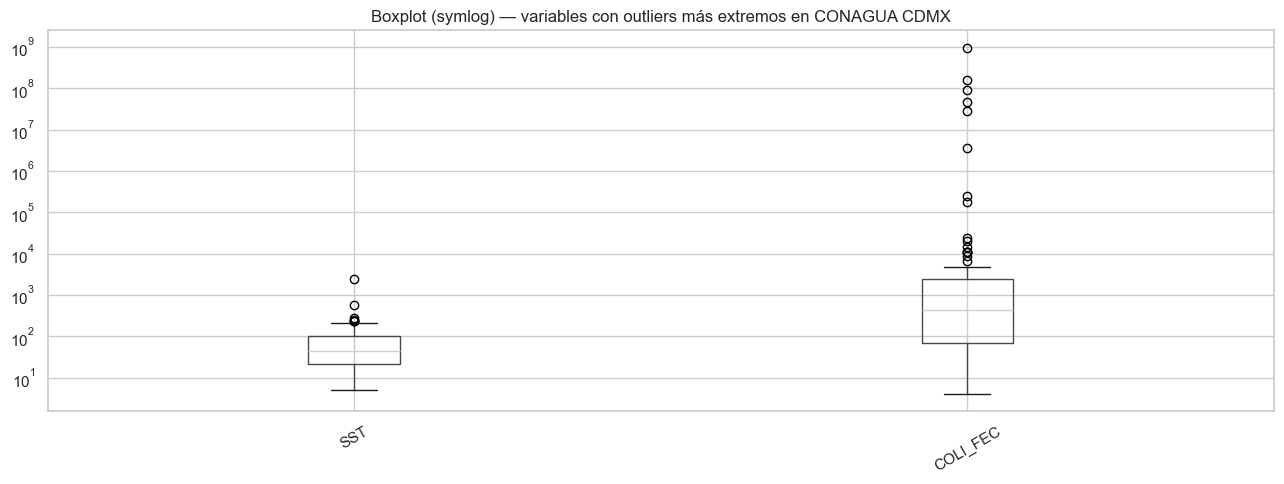

In [13]:
header("CONAGUA Resultados — Outliers por parámetro químico", level=2)

# Variables reguladas NOM-127 (NO se tocarán en limpieza; sólo se marcan)
COLS_REG_NOM127 = list(NOM_127.keys())

# Variables fisicoquímicas (candidatas a winsorizing en limpieza)
COLS_FISICOQUIMICAS = ["DBO_TOT", "DQO_TOT", "DBO_SOL", "DQO_SOL", "SST",
                       "COND_CAMPO", "TURBIEDAD_FAU", "ALK_TOT", "DUR_TOT",
                       "N_TOT", "N_NH3", "TEMP_AMB", "TEMP_AGUA"]


def perfil_outliers_columna(df, col):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(s) < 4:
        return None
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = int(((s < li) | (s > ls)).sum())
    p99 = float(s.quantile(0.99))
    return {
        "n_obs":          int(len(s)),
        "n_outliers":     n_out,
        "pct_outliers":   round(100 * n_out / len(s), 2),
        "min":            float(s.min()),
        "p99":            p99,
        "max":            float(s.max()),
        "ratio_max_p99":  round(s.max() / p99, 2) if p99 > 0 else None,
    }


filas_out = []
for col in COLS_REG_NOM127 + COLS_FISICOQUIMICAS:
    if col not in df_calidad_cdmx_view.columns:
        continue
    info = perfil_outliers_columna(df_calidad_cdmx_view, col)
    if info is None:
        continue
    info["columna"]    = col
    info["categoria"]  = "NOM-127 (preservar)" if col in COLS_REG_NOM127 else "fisicoquímica (winsorizar)"
    info["limite_NOM"] = NOM_127.get(col, {}).get("limite", None)
    filas_out.append(info)

df_outliers = pd.DataFrame(filas_out)
df_outliers = df_outliers[["columna", "categoria", "n_obs", "n_outliers",
                           "pct_outliers", "min", "p99", "max",
                           "ratio_max_p99", "limite_NOM"]]
print("Resumen de outliers por parámetro químico:")
display(df_outliers.sort_values("ratio_max_p99", ascending=False, na_position="last"))

# Visualización: boxplot symlog de las variables con mayor severidad
extremas = (df_outliers[df_outliers["ratio_max_p99"].fillna(0) > 5]
            .sort_values("ratio_max_p99", ascending=False)["columna"].head(6).tolist())
if extremas:
    df_plot = df_calidad_cdmx_view[extremas].apply(pd.to_numeric, errors="coerce")
    fig, ax = plt.subplots(figsize=(13, 5))
    df_plot.boxplot(ax=ax)
    ax.set_yscale("symlog")
    ax.set_title("Boxplot (symlog) — variables con outliers más extremos en CONAGUA CDMX")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Registrar hallazgo en el catálogo del perfilado
HALLAZGOS["conagua_result"].append(
    f"{len(extremas)} variables fisicoquímicas con ratio_max/p99 > 5 (candidatas a winsorizing)"
)

#### Consistencia química — DBO ≤ DQO

Por definición la Demanda Biológica de Oxígeno (parte biodegradable) no puede exceder la Demanda Química de Oxígeno (total oxidable). Si pasa, es error de laboratorio.

In [37]:
if {"DBO_TOT", "DQO_TOT"}.issubset(df_calidad_cdmx_view.columns):
    dbo = pd.to_numeric(df_calidad_cdmx_view["DBO_TOT"], errors="coerce")
    dqo = pd.to_numeric(df_calidad_cdmx_view["DQO_TOT"], errors="coerce")
    mask_eval = dbo.notna() & dqo.notna()
    n_evaluables_q = int(mask_eval.sum())
    n_violacion_q = int(((dbo > dqo) & mask_eval).sum())
    print(f"Mediciones evaluables: {n_evaluables_q:,}")
    print(f"Violaciones DBO > DQO: {n_violacion_q} ({100*n_violacion_q/max(n_evaluables_q,1):.2f}%)")
else:
    n_evaluables_q, n_violacion_q = 0, 0
    print("Columnas DBO_TOT / DQO_TOT no presentes en el subset; se omite la regla.")

Mediciones evaluables: 209
Violaciones DBO > DQO: 1 (0.48%)


In [38]:
# Score CONAGUA Resultados
# Usamos sólo columnas KEEP+IMPUTE para que la métrica sea representativa de la "porción usable"
cols_usables = catalogo_cols_conagua[catalogo_cols_conagua["accion"].isin(["KEEP", "IMPUTE"])]["columna"].tolist()
SCORECARD["conagua_result"]["Completitud"]  = score_completitud(df_calidad_cdmx_view, cols_usables)
SCORECARD["conagua_result"]["Validez"]      = np.nan  # se derivará de NOM-127 sec. 7
SCORECARD["conagua_result"]["Unicidad"]     = round(100 * (1 - df_calidad.duplicated(subset=["CLAVE SITIO", "FECHA REALIZACIÓN"]).sum() / max(len(df_calidad), 1)), 2)
SCORECARD["conagua_result"]["Consistencia"] = round(100 * (1 - n_violacion_q / max(n_evaluables_q, 1)), 2) if n_evaluables_q else np.nan
SCORECARD["conagua_result"]["Puntualidad"]  = np.nan
SCORECARD["conagua_result"]["Integridad"]   = np.nan  # se calcula en sec. 6
print({k: v for k, v in SCORECARD["conagua_result"].items()})

{'Completitud': 90.95, 'Validez': nan, 'Unicidad': 99.88, 'Consistencia': 99.52, 'Puntualidad': nan, 'Integridad': nan}


## 6. Integridad referencial cruzada

Dimensión DAMA muchas veces olvidada: **¿las claves foráneas resuelven?**. Aquí cuantificamos las roturas entre fuentes:

1. `Resultados_CONAGUA.CLAVE SITIO` → `Sitios_CONAGUA.CLAVE SITIO`
2. `SACMEX (alcaldía, colonia)` → `SEPOMEX (alcaldía, colonia)` *(ya calculado en 5.5; aquí lo registramos)*
3. `INEGI (NOM_MUN)` ↔ `CONEVAL (municipio)` — coherencia de población a nivel alcaldía

### 6.1 Resultados → Sitios (CONAGUA)

In [39]:
claves_resultados = set(df_calidad["CLAVE SITIO"].dropna().unique())
claves_sitios      = set(df_sitios["CLAVE SITIO"].dropna().unique())

huerfanos_res    = claves_resultados - claves_sitios
sitios_sin_med   = claves_sitios - claves_resultados

n_filas_huerf    = (~df_calidad["CLAVE SITIO"].isin(claves_sitios)).sum()
print(f"Resultados → Sitios:")
print(f"  CLAVE SITIO únicas en Resultados: {len(claves_resultados):,}")
print(f"  CLAVE SITIO únicas en Sitios:     {len(claves_sitios):,}")
print(f"  Claves de Resultados SIN metadata en Sitios: {len(huerfanos_res):,}")
print(f"  Filas afectadas en Resultados:               {n_filas_huerf:,} ({100*n_filas_huerf/len(df_calidad):.2f}%)")
print(f"  Sitios SIN ninguna medición:                 {len(sitios_sin_med):,}")

SCORECARD["conagua_result"]["Integridad"] = round(100 * (1 - n_filas_huerf / max(len(df_calidad), 1)), 2)
SCORECARD["conagua_sitios"]["Integridad"] = round(100 * (1 - len(sitios_sin_med) / max(len(claves_sitios), 1)), 2)

Resultados → Sitios:
  CLAVE SITIO únicas en Resultados: 7,771
  CLAVE SITIO únicas en Sitios:     7,771
  Claves de Resultados SIN metadata en Sitios: 0
  Filas afectadas en Resultados:               0 (0.00%)
  Sitios SIN ninguna medición:                 0


### 6.2 SACMEX ↔ SEPOMEX (registro)

In [40]:
# Ya tenemos n_filas_huerfanas calculado en 5.5
SCORECARD["sacmex_reportes"]["Integridad"] = round(100 * (1 - n_filas_huerfanas / max(len(df_sacmex), 1)), 2)
print(f"SACMEX → SEPOMEX (pares alcaldía-colonia):")
print(f"  Filas SACMEX sin match en SEPOMEX: {n_filas_huerfanas:,} ({100*n_filas_huerfanas/len(df_sacmex):.2f}%)")

SACMEX → SEPOMEX (pares alcaldía-colonia):
  Filas SACMEX sin match en SEPOMEX: 60,843 (19.39%)


### 6.3 INEGI ↔ CONEVAL — coherencia de población por alcaldía

Si las dos instituciones miden la misma población, los totales deben coincidir aproximadamente. Discrepancias > 5 % indican que la fusión a nivel municipio requiere reconciliación.

In [41]:
# INEGI: agregar localidades a alcaldía
df_loc_inegi = df_iter_cdmx[(df_iter_cdmx["LOC"] != 0) & (~df_iter_cdmx["LOC"].isin([9998, 9999]))].copy()
df_loc_inegi["NOM_MUN_NORM"] = normalizar_texto(df_loc_inegi["NOM_MUN"])
pob_inegi = df_loc_inegi.groupby("NOM_MUN_NORM")["POBTOT"].sum().reset_index()
pob_inegi.columns = ["alcaldia", "pob_INEGI"]

# CONEVAL: total por alcaldía año más reciente, grupo "Población total"
df_pob_2020 = df_pobreza_cdmx[df_pobreza_cdmx["anio"] == df_pobreza_cdmx["anio"].max()].copy()
df_pob_2020["municipio_norm"] = normalizar_texto(df_pob_2020["municipio"])
# Sumamos todos los grupos de edad (pueden estar desagregados)
pob_coneval = df_pob_2020.groupby("municipio_norm")["poblacion"].sum().reset_index()
pob_coneval.columns = ["alcaldia", "pob_CONEVAL"]

comparativa = pob_inegi.merge(pob_coneval, on="alcaldia", how="outer")
comparativa["dif_abs"] = (comparativa["pob_INEGI"] - comparativa["pob_CONEVAL"]).abs()
comparativa["err_pct"] = (comparativa["dif_abs"] / comparativa["pob_INEGI"] * 100).round(2)
display(comparativa.sort_values("err_pct", ascending=False))

# Alcaldías con error > 5%
n_discrepantes = (comparativa["err_pct"] > 5).sum()
n_total_alc = comparativa["alcaldia"].notna().sum()
print(f"\nAlcaldías con discrepancia > 5%: {n_discrepantes} de {n_total_alc}")
SCORECARD["inegi_iter"]["Integridad"]      = round(100 * (1 - n_discrepantes / max(n_total_alc, 1)), 2)
SCORECARD["coneval_pobreza"]["Integridad"] = round(100 * (1 - n_discrepantes / max(n_total_alc, 1)), 2)

,alcaldia,pob_INEGI,pob_CONEVAL,dif_abs,err_pct
2,BENITO JUAREZ,434153,373753,60400,13.91
10,MIGUEL HIDALGO,414470,364554,49916,12.04
5,CUAUHTEMOC,545884,491817,54067,9.90
4,CUAJIMALPA DE MORELOS,217686,199873,17813,8.18
3,COYOACAN,614447,568912,45535,7.41
7,IZTACALCO,404695,376977,27718,6.85
14,VENUSTIANO CARRANZA,443704,414915,28789,6.49
1,AZCAPOTZALCO,432205,404958,27247,6.30
11,MILPA ALTA,152685,161267,8582,5.62
0,ALVARO OBREGON,759137,726045,33092,4.36



Alcaldías con discrepancia > 5%: 9 de 16


## 7. Conformidad regulatoria — NOM‑127‑SSA1‑2021

Reportamos cuántas mediciones del subset CDMX **excederían** los límites de la NOM‑127 si el agua estuviera destinada a consumo humano. Como el agua de CONAGUA es **cruda** (cuerpos superficiales y acuíferos previa potabilización), una excedencia no implica que la planta SACMEX entregue agua fuera de norma; es una **señal de carga contaminante en la fuente**.

In [42]:
tabla_nom = conformidad_regulatoria(df_calidad_cdmx_view, NOM_127)
display(tabla_nom)

# Score Validez de CONAGUA Resultados: % de mediciones que NO exceden la NOM
total_med = tabla_nom["n_mediciones"].sum()
total_exc = tabla_nom["n_excede"].sum()
validez_nom = round(100 * (1 - total_exc / max(total_med, 1)), 2) if total_med > 0 else np.nan
SCORECARD["conagua_result"]["Validez"] = validez_nom
print(f"\n% de mediciones dentro de NOM-127: {validez_nom}% ({total_med - total_exc:,}/{total_med:,})")

,param,columna,limite,unidad,n_mediciones,n_excede,pct_excede,max_observado,ratio_max_vs_limite,nota
0,Arsénico,AS_TOT,0.010,mg/L,57,13,22.81,2.420000e-02,2.42,
1,Plomo,PB_TOT,0.010,mg/L,29,9,31.03,2.460000e-02,2.46,
2,Mercurio,HG_TOT,0.006,mg/L,29,1,3.45,7.930000e-03,1.32,
3,Cadmio,CD_TOT,0.005,mg/L,19,0,0.00,1.100000e-03,0.22,
4,Fluoruros,FLUORUROS_TOT,1.500,mg/L,16,0,0.00,6.690000e-01,0.45,
5,Nitratos,N_NO3,10.000,mg/L,183,3,1.64,1.719580e+01,1.72,
6,E. coli,E_COLI,0.000,NMP/100mL,133,133,100.00,5.172000e+07,NaN,
7,Coliformes fecales,COLI_FEC,0.000,NMP/100mL,137,137,100.00,9.606000e+08,NaN,



% de mediciones dentro de NOM-127: 50.91% (307/603)


### Visualización: severidad de excedencias por parámetro

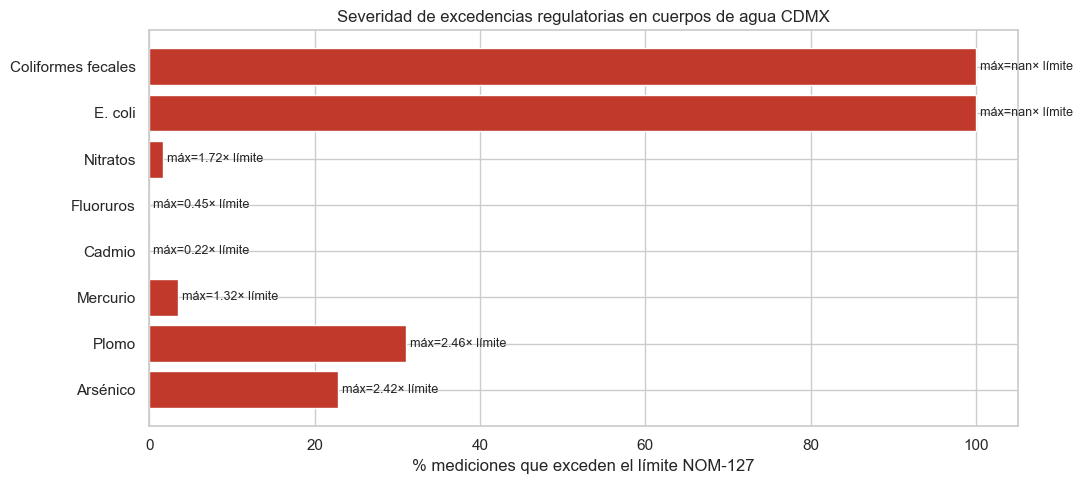

In [43]:
tabla_plot = tabla_nom.dropna(subset=["pct_excede"])
if len(tabla_plot) > 0:
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.barh(tabla_plot["param"], tabla_plot["pct_excede"], color="#c0392b")
    ax.set_xlabel("% mediciones que exceden el límite NOM-127")
    ax.set_title("Severidad de excedencias regulatorias en cuerpos de agua CDMX")
    for bar, ratio in zip(bars, tabla_plot["ratio_max_vs_limite"]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"máx={ratio}× límite", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No hay parámetros con datos suficientes para graficar.")

## 8. Cobertura de granularidad geográfica entre fuentes

El **Problema 4** del README es la mismatch de granularidad entre fuentes. Aquí la cuantificamos para que la fusión geoespacial tenga una base medida.

In [44]:
# Construcción de la matriz de granularidad
filas_gran = []

# Morbilidad: estado
filas_gran.append({"fuente": "morbilidad_ssa", "nivel_min": "estado",
                   "n_unidades_cdmx": int((df_morbi_cdmx['CVE_ESTADO'] == 9).sum() > 0)})
# INEGI: localidad
filas_gran.append({"fuente": "inegi_iter", "nivel_min": "localidad",
                   "n_unidades_cdmx": df_loc_inegi["NOM_LOC"].nunique()})
# CONEVAL: municipio (×grupo edad)
filas_gran.append({"fuente": "coneval_pobreza", "nivel_min": "municipio",
                   "n_unidades_cdmx": df_pobreza_cdmx["municipio"].nunique()})
# SEPOMEX: colonia
filas_gran.append({"fuente": "sepomex", "nivel_min": "colonia",
                   "n_unidades_cdmx": df_sepomex["nom_colonia"].nunique()})
# SACMEX: colonia (alcaldía+colonia)
filas_gran.append({"fuente": "sacmex_reportes", "nivel_min": "colonia",
                   "n_unidades_cdmx": df_sacmex.groupby(["alcaldia_catalogo","colonia_catalogo"]).ngroups})
# CONAGUA Sitios: punto (lat-lon)
filas_gran.append({"fuente": "conagua_sitios", "nivel_min": "punto",
                   "n_unidades_cdmx": df_calidad_cdmx_view["CLAVE SITIO"].nunique()})

df_granularidad = pd.DataFrame(filas_gran)
display(df_granularidad)

# Matriz alcaldías por fuente (¿quién registra a quién?)
alc_inegi   = set(normalizar_texto(df_loc_inegi["NOM_MUN"]).unique()) - {""}
alc_coneval = set(normalizar_texto(df_pobreza_cdmx["municipio"]).unique()) - {""}
alc_sepomex = set(normalizar_texto(df_sepomex["nom_alcaldia"]).unique()) - {""}
alc_sacmex  = set(normalizar_texto(df_sacmex["alcaldia_catalogo"]).unique()) - {""}

universo = alc_inegi | alc_coneval | alc_sepomex | alc_sacmex
matriz_alc = pd.DataFrame(index=sorted(universo))
matriz_alc["INEGI"]   = matriz_alc.index.isin(alc_inegi).astype(int)
matriz_alc["CONEVAL"] = matriz_alc.index.isin(alc_coneval).astype(int)
matriz_alc["SEPOMEX"] = matriz_alc.index.isin(alc_sepomex).astype(int)
matriz_alc["SACMEX"]  = matriz_alc.index.isin(alc_sacmex).astype(int)
matriz_alc["cobertura"] = matriz_alc.sum(axis=1)
print(f"\nAlcaldías universo (unión): {len(matriz_alc)}")
print(f"Alcaldías presentes en las 4 fuentes: {(matriz_alc['cobertura'] == 4).sum()}")
print(f"Alcaldías presentes en sólo 1 fuente: {(matriz_alc['cobertura'] == 1).sum()}")
display(matriz_alc.sort_values("cobertura"))

,fuente,nivel_min,n_unidades_cdmx
0,morbilidad_ssa,estado,1
1,inegi_iter,localidad,613
2,coneval_pobreza,municipio,16
3,sepomex,colonia,1382
4,sacmex_reportes,colonia,1607
5,conagua_sitios,punto,20



Alcaldías universo (unión): 16
Alcaldías presentes en las 4 fuentes: 16
Alcaldías presentes en sólo 1 fuente: 0


,INEGI,CONEVAL,SEPOMEX,SACMEX,cobertura
ALVARO OBREGON,1,1,1,1,4
AZCAPOTZALCO,1,1,1,1,4
BENITO JUAREZ,1,1,1,1,4
COYOACAN,1,1,1,1,4
CUAJIMALPA DE MORELOS,1,1,1,1,4
CUAUHTEMOC,1,1,1,1,4
GUSTAVO A. MADERO,1,1,1,1,4
IZTACALCO,1,1,1,1,4
IZTAPALAPA,1,1,1,1,4
LA MAGDALENA CONTRERAS,1,1,1,1,4


## 9. Data Quality Scorecard consolidado

Tabla y heatmap final que agrega los scores depositados durante el perfilado. Esta es la **vista ejecutiva**: si el revisor sólo lee una página de tu reporte, debe ser ésta.

> **Lectura de los scores:** valores cerca de 100 = dimensión "limpia"; valores < 90 indican focos de atención prioritaria para `limpieza.py`.

,Completitud,Validez,Unicidad,Consistencia,Puntualidad,Integridad
fuente,,,,,,
morbilidad_ssa,100.0,100.0,100.0,100.0,NaN,NaN
inegi_iter,89.0,NaN,NaN,NaN,NaN,43.8
coneval_pobreza,73.6,99.7,100.0,100.0,NaN,43.8
sepomex,100.0,37.4,100.0,100.0,NaN,NaN
conagua_sitios,84.8,99.9,100.0,NaN,NaN,100.0
conagua_result,91.0,50.9,99.9,99.5,NaN,100.0
sacmex_reportes,NaN,NaN,NaN,NaN,NaN,80.6


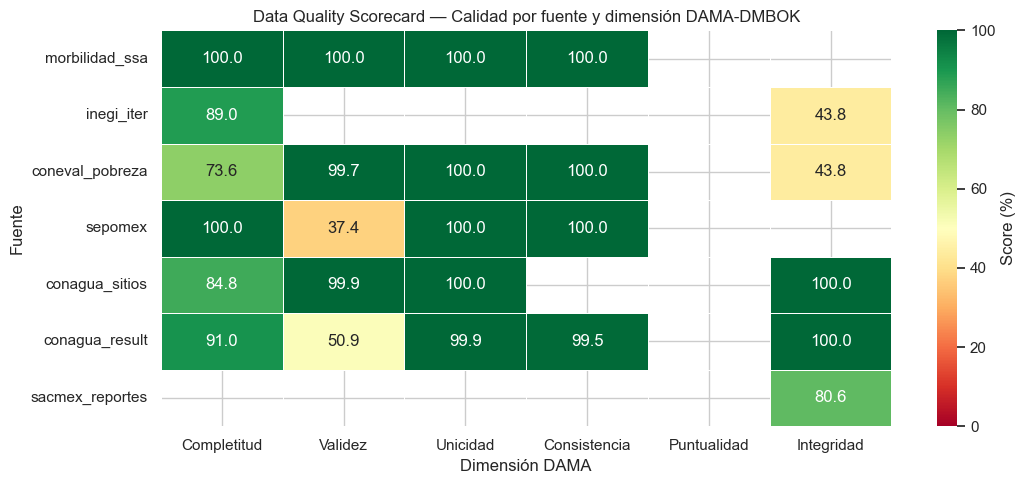


Score global por fuente:


,score_global
fuente,
morbilidad_ssa,100.00
conagua_sitios,96.20
conagua_result,88.25
sepomex,84.34
coneval_pobreza,83.41
sacmex_reportes,80.61
inegi_iter,66.35


In [45]:
DIMENSIONES = ["Completitud", "Validez", "Unicidad", "Consistencia", "Puntualidad", "Integridad"]

df_score = pd.DataFrame.from_dict(SCORECARD, orient="index")
df_score = df_score[DIMENSIONES]  # ordenar columnas
df_score.index.name = "fuente"
display(df_score.round(1))

# Heatmap
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(df_score.astype(float), annot=True, fmt=".1f", cmap="RdYlGn",
            vmin=0, vmax=100, cbar_kws={"label": "Score (%)"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Data Quality Scorecard — Calidad por fuente y dimensión DAMA-DMBOK")
ax.set_xlabel("Dimensión DAMA")
ax.set_ylabel("Fuente")
plt.tight_layout()
plt.show()

# Score global por fuente (media de las dimensiones aplicables)
df_score["score_global"] = df_score.mean(axis=1, skipna=True).round(2)
print("\nScore global por fuente:")
display(df_score[["score_global"]].sort_values("score_global", ascending=False))

## 10. Catálogo de fuentes — handoff a `limpieza.py`

Un único diccionario estructurado que `limpieza.py` puede importar para no repetir constantes. Contiene, por fuente:

* archivo y encoding
* claves lógicas (PK)
* filtros de scope
* códigos de missing
* hallazgos del perfilado
* score DAMA
* lista de acciones pendientes en limpieza

In [46]:
CATALOGO_FUENTES = {
    "morbilidad_ssa": {
        "archivo": str(RUTAS["morbilidad_ssa"]),
        "encoding": ENCODINGS_FORZADOS.get("morbilidad_ssa", inventario["morbilidad_ssa"]["encoding_usado"]),
        "pk_logica": ["CVE_ESTADO", "CVE_DIAGNO"],
        "filtro_cdmx": "CVE_ESTADO == 9",
        "missing_codes": MISSING_CODES["SSA"],
        "columnas_relevantes": COLS_BASE + COLS_EDAD_AMBOS + COLS_EDAD_F + COLS_TOTALES,
        "diagnosticos_hidricos": ENFERMEDADES_HIDRICAS,
        "score": dict(SCORECARD["morbilidad_ssa"]),
        "hallazgos": HALLAZGOS["morbilidad_ssa"],
        "acciones_limpieza": [
            "Verificar encoding contra mojibake",
            "Confirmar convención de columnas (suma) con diccionario oficial SSA",
            "Considerar imputación con 0 si la SSA documenta esa convención",
        ],
    },
    "inegi_iter": {
        "archivo": str(RUTAS["inegi_iter"]),
        "encoding": "utf-8-sig",
        "pk_logica": ["ENTIDAD", "MUN", "LOC"],
        "filtro_cdmx": "ENTIDAD == 9",
        "missing_codes": MISSING_CODES["INEGI"],
        "filtro_localidades_reales": "LOC != 0 AND LOC NOT IN (9998, 9999)",
        "columnas_relevantes": COLS_REL_INEGI,
        "score": dict(SCORECARD["inegi_iter"]),
        "hallazgos": HALLAZGOS["inegi_iter"],
        "acciones_limpieza": [
            "Eliminar filas de TOTALES (LOC=0) y CONFIDENCIALES (LOC=9998/9999) según necesidad",
            "Coercer columnas demográficas a numérico",
            "Validar coordenadas con shapefile oficial de INEGI (no sólo bounding box)",
        ],
    },
    "coneval_pobreza": {
        "archivo": str(RUTAS["coneval_pobreza"]),
        "encoding": "utf-8",
        "pk_logica": ["clave_municipio", "anio", "grupo"],
        "filtro_cdmx": "clave_entidad == 9",
        "missing_codes": MISSING_CODES["CONEVAL"],
        "columnas_pct": COLS_PCT_CONEVAL,
        "score": dict(SCORECARD["coneval_pobreza"]),
        "hallazgos": HALLAZGOS["coneval_pobreza"],
        "acciones_limpieza": [
            "Reemplazar -999.0 por NaN en columnas de porcentaje",
            "Validar regla pobreza ≤ ingreso<LPI antes de fusionar",
            "Estandarizar nombres de alcaldía (NFKD + upper) para fusión con SEPOMEX/SACMEX",
        ],
    },
    "sepomex": {
        "archivo": str(RUTAS["sepomex"]),
        "encoding": "utf-8-sig",
        "pk_logica": ["cve_alcaldia", "nom_colonia", "codigo_postal"],
        "score": dict(SCORECARD["sepomex"]),
        "hallazgos": HALLAZGOS["sepomex"],
        "acciones_limpieza": [
            "Padding de claves a longitud fija (estado=2, alcaldía=3, CP=5)",
            "Normalizar nombres de colonia para fuzzy matching con SACMEX",
        ],
    },
    "sacmex_reportes": {
        "archivo": str(RUTAS["sacmex_reportes"]),
        "encoding": "utf-8",
        "pk_logica": ["folio_incidente"],
        "score": dict(SCORECARD["sacmex_reportes"]),
        "hallazgos": HALLAZGOS["sacmex_reportes"],
        "alerta_scope": "Sólo cubre 2024-01. El histórico 2018-2022 debe agregarse antes de fusion.ipynb.",
        "acciones_limpieza": [
            "Parsear fecha_registro_incidente y fecha_reporte a datetime ISO",
            "Filtrar lag negativo (reporte antes que incidente) según política",
            "Reconciliar nombres de colonia con SEPOMEX (record-linkage)",
            "Filtrar coordenadas fuera del bounding box CDMX (o reportar como Edo. de México)",
        ],
    },
    "conagua_sitios": {
        "archivo": str(RUTAS["conagua_sitios"]),
        "encoding": "utf-8-sig",
        "pk_logica": ["CLAVE SITIO"],
        "score": dict(SCORECARD["conagua_sitios"]),
        "hallazgos": HALLAZGOS["conagua_sitios"],
        "acciones_limpieza": [
            "Coercer LATITUD/LONGITUD a numérico",
            "Filtrar sitios fuera del territorio mexicano",
        ],
    },
    "conagua_result": {
        "archivo": str(RUTAS["conagua_result"]),
        "encoding": "utf-8-sig",
        "pk_logica": ["CLAVE SITIO", "FECHA REALIZACIÓN"],
        "score": dict(SCORECARD["conagua_result"]),
        "hallazgos": HALLAZGOS["conagua_result"],
        "catalogo_columnas_path": "perfilado/catalogo_columnas_conagua.csv",
        "decisiones_columna": catalogo_cols_conagua["accion"].value_counts().to_dict(),
        "acciones_limpieza": [
            "DROP: descartar columnas con >95% nulos en CDMX (ver catálogo)",
            "FLAG: mantener columnas 30-95% sin imputar",
            "IMPUTE: imputar con KNN/MICE las de 5-30% nulos",
            "Parsear prefijos '<' y 'ND' (sustituir por L/2 según práctica EPA)",
            "Aplicar regla DBO ≤ DQO para filtrar errores de laboratorio",
        ],
    },
}

# Visualización
print("Catálogo de fuentes — vista resumida:")
for fuente, info in CATALOGO_FUENTES.items():
    score_g = pd.Series(info["score"]).mean(skipna=True).round(1)
    print(f"\n  • {fuente}  (score global ≈ {score_g})")
    print(f"      archivo:  {Path(info['archivo']).name}")
    print(f"      encoding: {info.get('encoding','-')}")
    print(f"      pk:       {info.get('pk_logica','-')}")
    print(f"      acciones de limpieza pendientes: {len(info['acciones_limpieza'])}")

Catálogo de fuentes — vista resumida:

  • morbilidad_ssa  (score global ≈ 100.0)
      archivo:  Anuario_Morbilidad_2017.csv
      encoding: cp1252
      pk:       ['CVE_ESTADO', 'CVE_DIAGNO']
      acciones de limpieza pendientes: 3

  • inegi_iter  (score global ≈ 66.4)
      archivo:  conjunto_de_datos_iter_00CSV20.csv
      encoding: utf-8-sig
      pk:       ['ENTIDAD', 'MUN', 'LOC']
      acciones de limpieza pendientes: 3

  • coneval_pobreza  (score global ≈ 83.4)
      archivo:  pobreza_grupos_poblacionales_edad.csv
      encoding: utf-8
      pk:       ['clave_municipio', 'anio', 'grupo']
      acciones de limpieza pendientes: 3

  • sepomex  (score global ≈ 84.3)
      archivo:  catalogo_sepomex.csv
      encoding: utf-8-sig
      pk:       ['cve_alcaldia', 'nom_colonia', 'codigo_postal']
      acciones de limpieza pendientes: 2

  • sacmex_reportes  (score global ≈ 80.6)
      archivo:  reportes_agua_2024_01.csv
      encoding: utf-8
      pk:       ['folio_incidente']
   

### Persistencia opcional del catálogo

Si quieres que `limpieza.py` lea estas decisiones desde disco, descomenta el bloque siguiente. Genera dos artefactos en `PROJECT_ROOT/perfilado/`:
* `catalogo_fuentes.yaml` — el catálogo completo
* `catalogo_columnas_conagua.csv` — la tabla de decisión por columna

In [ ]:
# import yaml
# out_dir = PROJECT_ROOT / "perfilado"
# out_dir.mkdir(exist_ok=True)
#
# with open(out_dir / "catalogo_fuentes.yaml", "w", encoding="utf-8") as f:
#     yaml.safe_dump(CATALOGO_FUENTES, f, allow_unicode=True, sort_keys=False)
#
# catalogo_cols_conagua.to_csv(out_dir / "catalogo_columnas_conagua.csv", index=False, encoding="utf-8-sig")
# print(f"✅ Artefactos guardados en {out_dir}")

## 11. Conclusiones del perfilado

### 11.1 Estado por fuente

| Fuente | Estado general | Acción crítica para `limpieza.py` |
|---|---|---|
| **Morbilidad SSA 2017** | Estructuralmente completa, sin duplicados | Verificar convención de columnas con el diccionario oficial de la SSA |
| **INEGI ITER 2020** | Completitud y consistencia altas en localidades reales | Filtrar filas de totales (LOC=0) y confidenciales (LOC=9998/9999) |
| **CONEVAL pobreza** | -999 contamina la completitud aparente; revelar el missing real | Sustituir -999 por NaN, normalizar nombres de alcaldía |
| **SEPOMEX** | Catálogo limpio, eje de fusión territorial | Padding de claves para joins consistentes |
| **SACMEX** | El dataset crítico; concentra más problemas | Parseo de fechas, filtrado de lag negativo, record-linkage con SEPOMEX, **agregar histórico 2018-2022** |
| **CONAGUA Sitios** | Catálogo nacional sólido | Coerción numérica de coordenadas |
| **CONAGUA Resultados** | 469 columnas, alta dispersión | Aplicar tabla de decisión por columna; parsear `<` y `ND` |

### 11.2 Hallazgos transversales

1. **El cuello de botella geográfico es real.** La granularidad de las fuentes va desde *estado* (morbilidad) hasta *punto* (CONAGUA), pasando por *municipio* (CONEVAL) y *colonia* (SACMEX/SEPOMEX). Cualquier análisis a nivel colonia exige distribuir métricas de niveles superiores con un supuesto declarado (por ejemplo, proporción de población).
2. **El desfase temporal es la otra cara del problema.** Morbilidad 2017 + INEGI 2020 + SACMEX 2024. Cualquier afirmación causal del proyecto debe llevar la advertencia de heterogeneidad temporal en el reporte final.
3. **CONAGUA en CDMX no es agua potable.** Las excedencias NOM-127 reportadas en la sección 7 corresponden a cuerpos de agua *cruda*; la planta potabilizadora es justamente la que debe corregirlas. Eso convierte el indicador en una métrica de *carga contaminante en la fuente*, no de incumplimiento legal.
4. **SACMEX 2024-01 sólo cubre un mes.** El Problema 3 (Puntualidad, predicción de fugas) requiere el histórico completo. Tarea bloqueante antes de `fusion.ipynb`.

### 11.3 Métricas de éxito del perfilado

* ✅ Las 6 dimensiones DAMA evaluadas en cada fuente.
* ✅ Reglas de negocio formalizadas como contratos verificables.
* ✅ Integridad referencial cruzada cuantificada.
* ✅ Tabla de decisión por columna para CONAGUA Resultados.
* ✅ Conformidad regulatoria NOM-127 calculada.
* ✅ Scorecard consolidado entregado como artefacto principal.
* ✅ Catálogo de fuentes serializable como contrato hacia `limpieza.py`.

### 11.4 Próximos pasos

1. Implementar `limpieza.py` consumiendo `CATALOGO_FUENTES`.
2. Agregar el histórico SACMEX 2018-2022.
3. Resolver la convención de columnas de morbilidad con el diccionario oficial.
4. Ejecutar `fusion.ipynb` con record-linkage SACMEX↔SEPOMEX y SACMEX↔CONAGUA.

---
*Notebook generado el 2026-05-01.*
